# 01 — Raw Data EDA

Explores the **raw** Bronze snapshot to measure data-quality problems *before* any cleaning, and turns them into concrete requirements for the Silver stage.

| | |
|---|---|
| **Objective** | Measure completeness, validity, consistency and source differences of raw listings. |
| **Input** | `data/bronze/snapshot/` (Parquet + `metadata.json`, SHA-256 verified) |
| **Output** | Findings and cleaning requirements (no files are written) |
| **Principles** | Bronze = source truth · measure before cleaning · never modify, impute or delete raw values · source share ≠ market share · all numbers are computed at runtime |

**Contents**

- Setup
- 01. Dataset Overview
- 02. Data Structure & Integrity
- 03. Missing Data Analysis & Treatment
- 04. Numeric Quality, Outliers & Treatment
- 05. Text Quality Analysis
- 06. Address & Location Quality
- 07. Source-Level Data Quality
- 08. Cross-variable Relationship Analysis
- 09. RoomBeacon Data Readiness
- 10. Data Quality Findings
- 11. Cleaning & Processing Requirements
- Summary

## Where this notebook sits

```mermaid
flowchart LR
    BR[("Bronze snapshot<br/>Parquet")] --> NB01 & NB02
    NB02 --> SV[("Silver<br/>rental_listings.parquet")]
    SV --> NB03 --> NB04 --> CH[("Locked champion<br/>LightGBM F4 RAW")]
    SV --> NB05
    CH --> NB06 & NB07
    NB01["01 · Raw EDA"]
    NB02["02 · Bronze → Silver"]
    NB03["03 · Feature contract"]
    NB04["04 · Price model"]
    NB05["05 · Nearby search"]
    NB06["06 · Shadow validation"]
    NB07["07 · Performance"]
    classDef current fill:#2a78d6,color:#ffffff,stroke:#184f95
    class NB01 current
```

The highlighted step is this notebook.

## How this EDA is organised

```mermaid
flowchart LR
    A["01–02<br/>What is in the data?"] --> B["03–07<br/>Where is it incomplete<br/>or inconsistent?"]
    B --> C["08<br/>How do fields relate?"]
    C --> D["09<br/>How much is ready<br/>for processing?"]
    D --> E["10–11<br/>Findings &<br/>cleaning requirements"]
```

Parsers and ward mapping are applied only to **temporary audit columns** to measure problems; `df` is
never overwritten.

## Setup

In [77]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    p
    for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "crawler").is_dir() and (p / "analytics").is_dir()
)
sys.path.insert(0, str(PROJECT_ROOT))

from notebooks.utils import setup_project_path

PROJECT_ROOT = setup_project_path()

from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from IPython.display import Markdown, display

from analytics.bronze.snapshot import load_bronze_snapshot
from notebooks.utils.address_parser import apply_address_parsing
from notebooks.utils.location_analysis import audit_coordinate_trust
from notebooks.utils.notebook_style import (
    CATEGORICAL,
    apply_style,
    bar_chart,
    box_chart,
    funnel_chart,
    heatmap,
    histogram,
    range_chart,
    scatter_legend,
    status_chart,
)
from notebooks.utils.silver_reporting import STATUS_TIERS
from notebooks.utils.ward_normalization import apply_ward_mapping

load_dotenv(PROJECT_ROOT / ".env", override=False)
apply_style()
pd.set_option("display.max_rows", 16)
pd.set_option("display.max_columns", 12)

Đã phát hiện thư mục gốc của dự án RoomBeacon: /data/projects/roombeacon/source/roombeacon-system


ImportError: cannot import name 'box_chart' from 'notebooks.utils.notebook_style' (/data/projects/roombeacon/source/roombeacon-system/notebooks/utils/notebook_style.py)

**Runtime data scope.** The notebook reads the local Bronze snapshot once (one row per `rental_post_id`).
Raw price/area evidence is matched to the version that produced the current values. Refreshing the
snapshot is an explicit Airflow step (`roombeacon_bronze_snapshot`), never a notebook side effect.

In [ ]:
SNAPSHOT_DIR = PROJECT_ROOT / "data" / "bronze" / "snapshot"
load_started = perf_counter()
df_latest, raw_evidence, run_context = load_bronze_snapshot(SNAPSHOT_DIR)
local_load_seconds = perf_counter() - load_started

display(
    pd.Series(
        {
            "Snapshot ID": run_context["snapshot_id"],
            "Snapshot created (UTC)": run_context["snapshot_created_at_utc"],
            "Latest rows": f"{len(df_latest):,}",
            "Unique rental_post_id": f"{df_latest['rental_post_id'].nunique():,}",
            "Raw evidence rows": f"{len(raw_evidence):,}",
            "Load seconds": round(local_load_seconds, 3),
        },
        name="value",
    ).to_frame()
)

,value
Snapshot ID,db804eae-1774-4659-aa9a-255830997f5d
Snapshot created (UTC),2026-10-07T10:03:08.735593+00:00
Latest rows,"132,494"
Unique rental_post_id,"132,494"
Raw evidence rows,"132,494"
Load seconds,0.5


## 01. Dataset Overview

> **Why:** Know the size, grain, sources and time span before judging quality.

### 01.1 Load, shape & grain

The analysis reuses the in-memory snapshot; Bronze is not rescanned.

In [ ]:
df = df_latest.copy()
assert len(df) == df["rental_post_id"].nunique(), "Grain violation: rental_post_id is not unique."
display(
    pd.Series(
        {
            "Rows": f"{len(df):,}",
            "Columns": df.shape[1],
            "Grain": "1 row = 1 rental_post_id (verified)",
        },
        name="value",
    ).to_frame()
)
df.head(5)

,value
Rows,"132,494"
Columns,20
Grain,1 row = 1 rental_post_id (verified)


,source_code,rental_post_id,source_listing_id,title_raw,url,price_amount,...,best_address_text,best_address_source,latest_observed_at,first_observed_at,last_observed_at,active_days
0,mogi,53598,22753131,Cho Thuê Phòng Q3 rộng rãi thoải mái.cửa sổ nộ...,https://mogi.vn/quan-3/thue-phong-tro-khu-nha-...,3000000.0,...,"Lý Chính Thắng, Phường 7 (Phường Võ Thị Sáu), ...",source_detail,2026-09-28 07:50:50,2026-09-20 12:47:38,2026-09-28 07:50:50,8
1,mogi,53599,22734471,Cho Thuê Phòng Q3.đầy đủ nội thất.cửa sổ ban c...,https://mogi.vn/quan-3/thue-phong-tro-khu-nha-...,3000000.0,...,"Nguyễn Thiện Thuật, Phường 3, Quận 3, TPHCM",source_detail,2026-09-25 20:20:14,2026-09-20 12:47:41,2026-09-25 20:20:14,5
2,mogi,53600,22731713,Phòng Bùi Hữu Nghĩa thang máy bảo vệ 24/7 kế C...,https://mogi.vn/quan-binh-thanh/thue-phong-tro...,5000000.0,...,"Bùi Hữu Nghĩa, Phường 2, Quận Bình Thạnh, TPHCM",source_detail,2026-09-28 07:45:33,2026-09-20 12:47:44,2026-09-28 07:45:33,8
3,mogi,53601,21964636,🏡Phòng Trọ Giá Rẻ 30m2 - Full Nội Thất + Ban C...,https://mogi.vn/quan-tan-binh/thue-phong-tro-k...,3000000.0,...,"Trường Chinh, Phường 15, Quận Tân Bình, TPHCM",source_detail,2026-09-28 09:44:50,2026-09-20 12:47:47,2026-09-28 09:44:50,8
4,mogi,53602,21964621,🏡 PHÒNG TRỌ GIÁ RẺ Mới 100% - Full Nội Thất - ...,https://mogi.vn/quan-tan-binh/thue-phong-tro-k...,3000000.0,...,"Trường Chinh, Phường 15, Quận Tân Bình, TPHCM",source_detail,2026-09-28 09:44:50,2026-09-20 12:47:50,2026-09-28 09:44:50,8


### 01.2 Field overview

Coverage = rows with a value ÷ all rows.

In [ ]:
field_overview = pd.DataFrame(
    {
        "Field": df.columns,
        "Data type": df.dtypes.astype(str).values,
        "Available rows": df.notna().sum().values,
        "Coverage (%)": (df.notna().mean().values * 100).round(2),
        "Unique values": df.nunique(dropna=True).values,
    }
)
field_overview

,Field,Data type,Available rows,Coverage (%),Unique values
0,source_code,str,132494,100.00,9
1,rental_post_id,int64,132494,100.00,132494
2,source_listing_id,str,132494,100.00,132494
3,title_raw,str,131971,99.61,123191
4,url,str,132494,100.00,132482
...,...,...,...,...,...
15,best_address_source,str,132494,100.00,3
16,latest_observed_at,datetime64[us],132494,100.00,93292
17,first_observed_at,datetime64[us],132494,100.00,18073
18,last_observed_at,datetime64[us],132494,100.00,93286


### 01.3 Source distribution

Source share describes what the crawler collected, not market share.

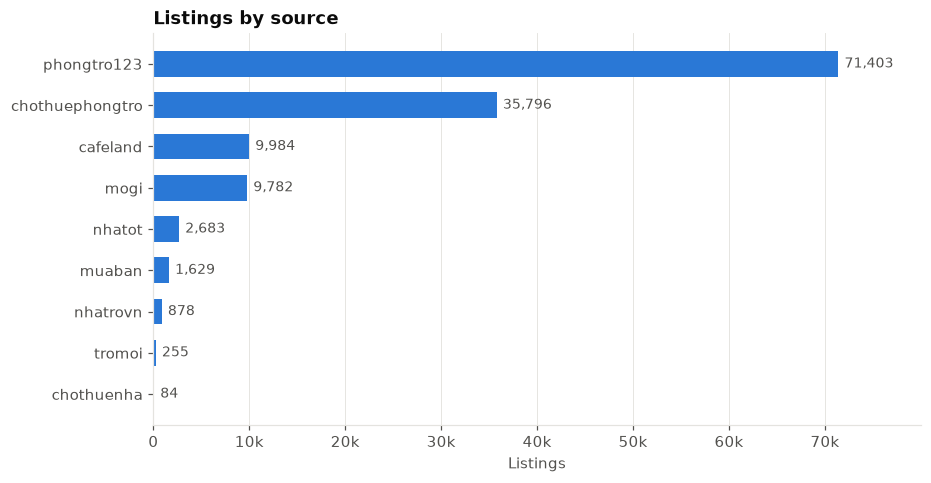

,Share (%)
source_code,
phongtro123,53.89
chothuephongtro,27.02
cafeland,7.54
mogi,7.38
nhatot,2.02
muaban,1.23
nhatrovn,0.66
tromoi,0.19
chothuenha,0.06


In [ ]:
source_distribution = df["source_code"].value_counts(dropna=False)
bar_chart(source_distribution, title="Listings by source", xlabel="Listings")
plt.show()
display((source_distribution / len(df) * 100).round(2).rename("Share (%)").to_frame())

### 01.4 Temporal coverage

When were listings first seen? Each bar is one day.

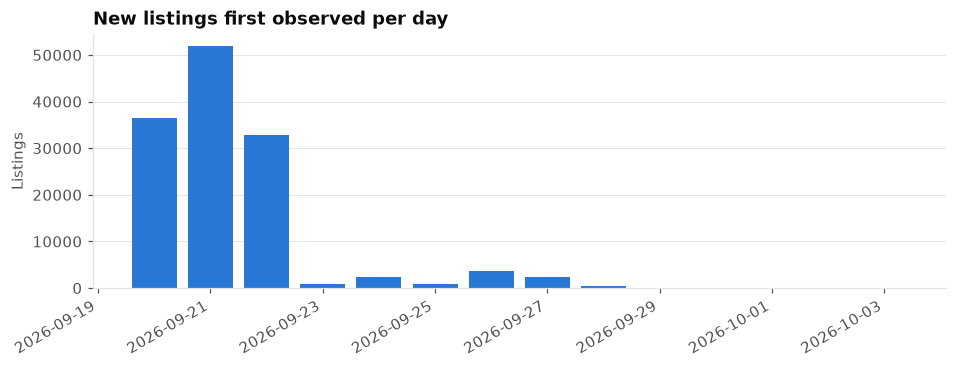

,time
Earliest observation,2026-09-20 12:47:03
Latest observation,2026-10-03 09:57:20


In [ ]:
first_seen = pd.to_datetime(df["first_observed_at"]).dt.floor("D").value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(first_seen.index, first_seen.values, color=CATEGORICAL[0], width=0.8)
ax.set(title="New listings first observed per day", ylabel="Listings")
ax.grid(axis="y")
ax.grid(axis="x", visible=False)
fig.autofmt_xdate()
plt.show()
display(
    pd.Series(
        {
            "Earliest observation": df["first_observed_at"].min(),
            "Latest observation": df["last_observed_at"].max(),
        },
        name="time",
    ).to_frame()
)

## 02. Data Structure & Integrity

> **Why:** Verify identifiers, duplicates, timestamps and basic ranges are structurally sound.

### 02.1 Identifier integrity

In [ ]:
identifier_integrity = pd.Series(
    {
        "Missing rental_post_id": df["rental_post_id"].isna().sum(),
        "Duplicate rental_post_id": df["rental_post_id"].duplicated().sum(),
        "Missing source": df["source_code"].isna().sum(),
        "Missing source listing ID": df["source_listing_id"].isna().sum(),
        "Duplicate source + listing ID": df.duplicated(
            subset=["source_code", "source_listing_id"]
        ).sum(),
    },
    name="Rows",
).to_frame()
identifier_integrity

,Rows
Missing rental_post_id,0
Duplicate rental_post_id,0
Missing source,0
Missing source listing ID,0
Duplicate source + listing ID,0


### 02.2 Duplicate records

Identical rows or repeated URLs may indicate the same listing collected twice.

In [ ]:
duplicate_checks = pd.Series(
    {
        "Fully identical rows": df.duplicated().sum(),
        "Rows with repeated URLs": df["url"].duplicated(keep=False).sum(),
    },
    name="Rows",
).to_frame()
display(duplicate_checks)
df.loc[df["url"].duplicated(keep=False)].sort_values("url")[
    ["source_code", "rental_post_id", "source_listing_id", "url"]
].head(10)

,Rows
Fully identical rows,0
Rows with repeated URLs,24


,source_code,rental_post_id,source_listing_id,url
23545,chothuephongtro,84093,162597,https://chothuephongtro.me/cho-thue-can-duplex...
23526,chothuephongtro,84074,162663,https://chothuephongtro.me/cho-thue-can-duplex...
22684,chothuephongtro,83101,162835,https://chothuephongtro.me/cho-thue-cc-mini-da...
24633,chothuephongtro,85326,161853,https://chothuephongtro.me/cho-thue-cc-mini-da...
21671,chothuephongtro,81926,163495,https://chothuephongtro.me/chung-cu-mini-thang...
23698,chothuephongtro,84246,162248,https://chothuephongtro.me/chung-cu-mini-thang...
50334,chothuephongtro,118329,ho-chi-minh/quan-7,https://chothuephongtro.me/ho-chi-minh/quan-7....
61006,chothuephongtro,152255,ho-chi-minh/quan-7/149628,https://chothuephongtro.me/ho-chi-minh/quan-7....
16012,chothuephongtro,75386,165274,https://chothuephongtro.me/phong-dep-gia-re-ng...
16014,chothuephongtro,75388,165273,https://chothuephongtro.me/phong-dep-gia-re-ng...


### 02.3 Temporal consistency & basic ranges

Structurally impossible values only; unusual but possible values are handled as outliers later.

In [ ]:
range_checks = {
    "first_observed_at after latest_observed_at": df["first_observed_at"]
    > df["latest_observed_at"],
    "first_observed_at after last_observed_at": df["first_observed_at"] > df["last_observed_at"],
    "Negative active_days": df["active_days"] < 0,
    "Latitude outside [-90, 90]": df["map_latitude"].notna() & ~df["map_latitude"].between(-90, 90),
    "Longitude outside [-180, 180]": df["map_longitude"].notna()
    & ~df["map_longitude"].between(-180, 180),
    "Negative price_amount": pd.to_numeric(df["price_amount"], errors="coerce") < 0,
    "Negative area_value": pd.to_numeric(df["area_value"], errors="coerce") < 0,
}
basic_range_checks = pd.Series(
    {issue: int(mask.sum()) for issue, mask in range_checks.items()}, name="Rows"
).to_frame()
basic_range_checks

,Rows
first_observed_at after latest_observed_at,0
first_observed_at after last_observed_at,5
Negative active_days,0
"Latitude outside [-90, 90]",0
"Longitude outside [-180, 180]",0
Negative price_amount,0
Negative area_value,0


## 03. Missing Data Analysis & Treatment

> **Why:** Find which fields are missing, how much, where (by source) and why, then choose a treatment per field.

**Process:** detect → locate (field, source, co-missing) → explain the mechanism → compare treatments on a
copy → decide. A value counts as missing when it is null, empty or whitespace only.

### 03.1 Overall missingness

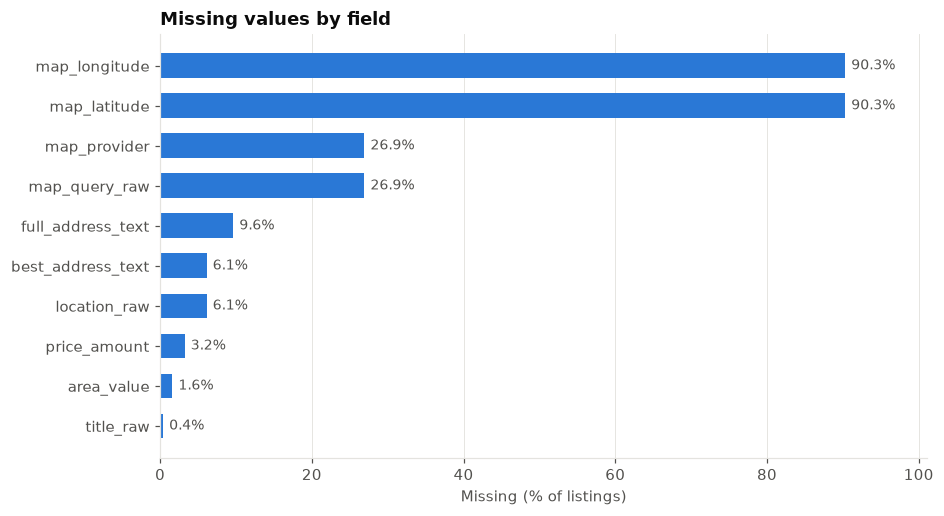

**10** of 20 fields are complete; **10** have gaps.

In [ ]:
missing_flags = df.isna()
text_fields = df.select_dtypes(include=["object", "string"]).columns
missing_flags[text_fields] |= df[text_fields].apply(
    lambda column: column.astype("string").str.fullmatch(r"\s*", na=False)
)
missing_summary = pd.DataFrame(
    {
        "Field": df.columns,
        "Missing rows": missing_flags.sum().values,
        "Missing (%)": (missing_flags.mean().values * 100).round(2),
    }
).sort_values("Missing (%)", ascending=False)

with_missing = missing_summary.loc[missing_summary["Missing rows"] > 0].set_index("Field")[
    "Missing (%)"
]
bar_chart(
    with_missing, title="Missing values by field", xlabel="Missing (% of listings)", fmt="{:.1f}%"
)
plt.show()
display(
    Markdown(
        f"**{(missing_summary['Missing rows'] == 0).sum()}** of {len(df.columns)} fields are complete; "
        f"**{len(with_missing)}** have gaps."
    )
)

### 03.2 Missingness by source

Darker = more missing. A gap that belongs to one source points to a crawler/parser issue, not to the market.

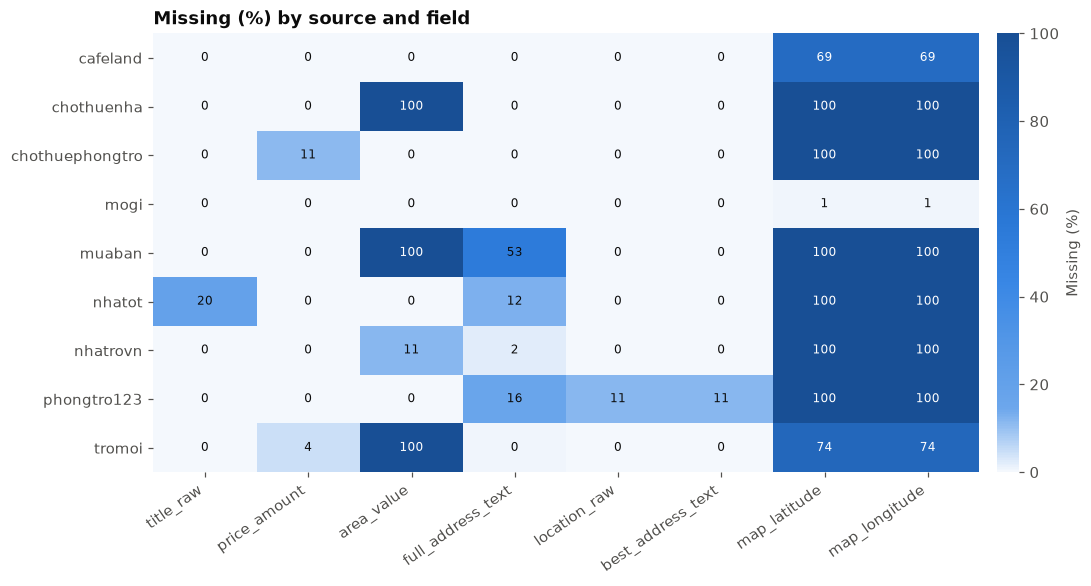

In [ ]:
important_fields = [
    "title_raw",
    "price_amount",
    "area_value",
    "full_address_text",
    "location_raw",
    "best_address_text",
    "map_latitude",
    "map_longitude",
]
missingness_by_source = (
    missing_flags.groupby(df["source_code"])[important_fields].mean().mul(100).round(1)
)
heatmap(
    missingness_by_source, title="Missing (%) by source and field", vmax=100, label="Missing (%)"
)
plt.show()

### 03.3 Missing patterns

Do important fields go missing together, and how many gaps does one listing carry?

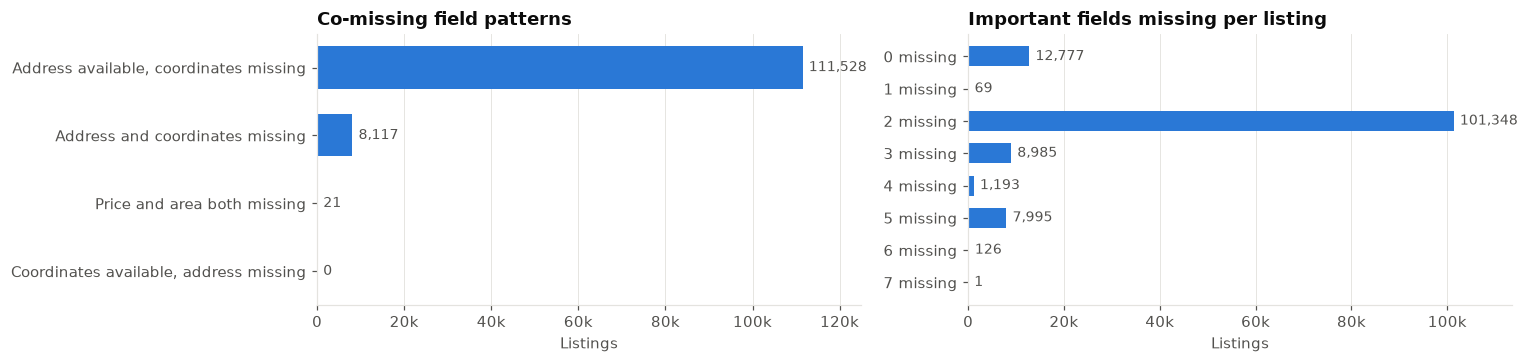

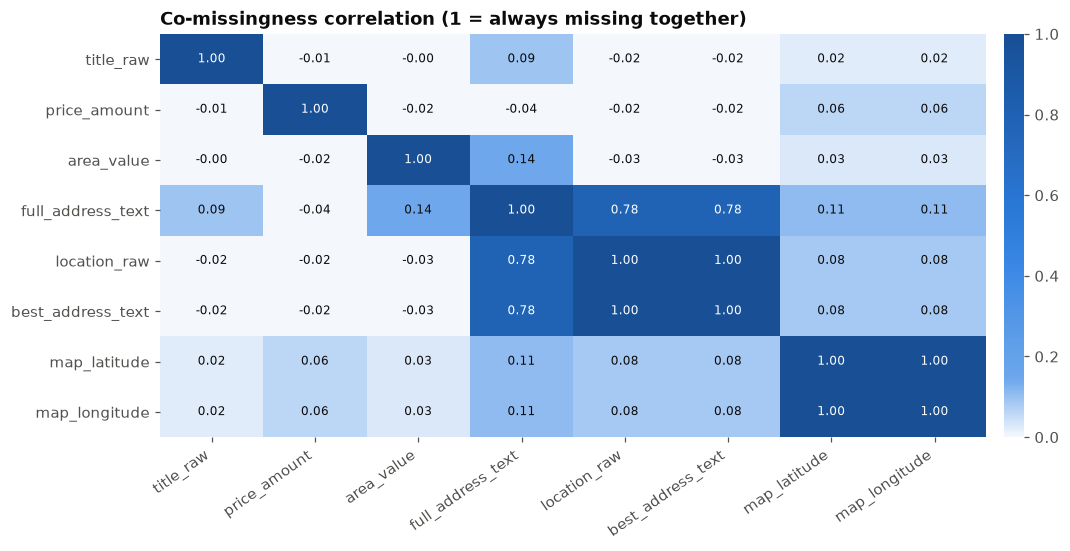

In [ ]:
coordinates_missing = missing_flags["map_latitude"] | missing_flags["map_longitude"]
missing_patterns = pd.Series(
    {
        "Price and area both missing": (
            missing_flags["price_amount"] & missing_flags["area_value"]
        ).sum(),
        "Address available, coordinates missing": (
            ~missing_flags["best_address_text"] & coordinates_missing
        ).sum(),
        "Coordinates available, address missing": (
            missing_flags["best_address_text"] & ~coordinates_missing
        ).sum(),
        "Address and coordinates missing": (
            missing_flags["best_address_text"] & coordinates_missing
        ).sum(),
    }
)
missing_per_row = missing_flags[important_fields].sum(axis=1)
fig, (left, right) = plt.subplots(1, 2, figsize=(14, 3.4))
bar_chart(missing_patterns, title="Co-missing field patterns", xlabel="Listings", ax=left)
bar_chart(
    missing_per_row.value_counts().sort_index().rename(lambda n: f"{n} missing"),
    sort=False,
    title="Important fields missing per listing",
    xlabel="Listings",
    ax=right,
)
plt.tight_layout()
plt.show()
co_missingness = missing_flags[important_fields].astype(int).corr().fillna(0)
heatmap(
    co_missingness,
    title="Co-missingness correlation (1 = always missing together)",
    fmt="{:.2f}",
    vmax=1,
)
plt.show()

### 03.4 Missing mechanism

If a field is missing almost only in a few sources, the gap is **structural** (the site does not publish it) — not random, so filling it with a global value would invent information.

In [ ]:
mechanism_rows = []
for field in important_fields:
    rate = missing_flags[field].mean() * 100
    if rate == 0:
        continue
    by_source = missing_flags.groupby(df["source_code"])[field].mean() * 100
    share_from_worst = (
        missing_flags[field].groupby(df["source_code"]).sum().max()
        / missing_flags[field].sum()
        * 100
    )
    structural = by_source.ge(95).any() or share_from_worst >= 70
    mechanism_rows.append(
        {
            "Field": field,
            "Missing (%)": round(rate, 2),
            "Sources ≥ 95% missing": ", ".join(by_source.index[by_source.ge(95)]) or "—",
            "Share from one source (%)": round(share_from_worst, 1),
            "Mechanism": (
                "Structural (source does not publish)"
                if structural
                else "Sporadic (listing-level gap)"
            ),
        }
    )
missing_mechanism = pd.DataFrame(mechanism_rows)
missing_mechanism

,Field,Missing (%),Sources ≥ 95% missing,Share from one source (%),Mechanism
0,title_raw,0.39,—,100.0,Structural (source does not publish)
1,price_amount,3.23,—,94.3,Structural (source does not publish)
2,area_value,1.61,"chothuenha, muaban, tromoi",76.4,Structural (source does not publish)
3,full_address_text,9.64,—,90.3,Structural (source does not publish)
4,location_raw,6.13,—,100.0,Structural (source does not publish)
5,best_address_text,6.13,—,100.0,Structural (source does not publish)
6,map_latitude,90.30,"chothuenha, chothuephongtro, muaban, nhatot, n...",59.7,Structural (source does not publish)
7,map_longitude,90.30,"chothuenha, chothuephongtro, muaban, nhatot, n...",59.7,Structural (source does not publish)


### 03.5 Treatment options compared (on a copy)

What would each common strategy do to the dataset? `df` itself is never changed.

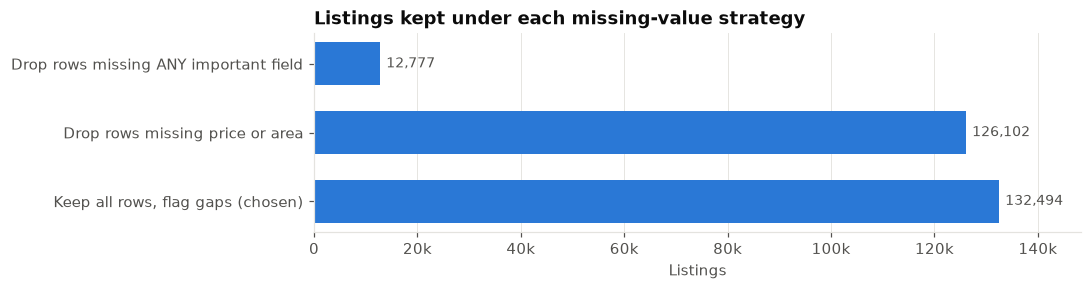

,count,mean,std,25%,50%,75%
Raw price (non-missing),128213.0,5.950048e+06,3.033024e+08,3000000.0,4000000.0,5000000.0
After global-median imputation,132494.0,5.887040e+06,2.983623e+08,3000000.0,4000000.0,5000000.0


Dropping rows with any important gap keeps only **9.6%** of listings — almost all losses come from coordinates, which most sources never publish. Median imputation of price shrinks the spread and fabricates rents for listings that never stated one. Both are rejected.

In [ ]:
df_before = df.copy(deep=True)
target_fields = ["price_amount", "area_value"]

strategies = {
    "Drop rows missing ANY important field": ~missing_flags[important_fields].any(axis=1),
    "Drop rows missing price or area": ~missing_flags[target_fields].any(axis=1),
    "Keep all rows, flag gaps (chosen)": pd.Series(True, index=df.index),
}
retained = pd.Series({name: int(mask.sum()) for name, mask in strategies.items()})
bar_chart(
    retained, sort=False, title="Listings kept under each missing-value strategy", xlabel="Listings"
)
plt.show()

price_raw = pd.to_numeric(df["price_amount"], errors="coerce")
imputed = price_raw.fillna(price_raw.median())
display(
    pd.DataFrame(
        {
            "Raw price (non-missing)": price_raw.describe(percentiles=[0.25, 0.5, 0.75]),
            "After global-median imputation": imputed.describe(percentiles=[0.25, 0.5, 0.75]),
        }
    ).T[["count", "mean", "std", "25%", "50%", "75%"]]
)
pd.testing.assert_frame_equal(df, df_before)  # the simulation did not modify df
display(
    Markdown(
        f"Dropping rows with any important gap keeps only **{retained.iloc[0] / len(df):.1%}** of listings — almost all "
        "losses come from coordinates, which most sources never publish. Median imputation of price shrinks the spread "
        "and fabricates rents for listings that never stated one. Both are rejected."
    )
)

### 03.6 Missing-value treatment decision

Applied in Notebook 02 (Silver); the raw value always stays unchanged next to the decision.

In [ ]:
missing_treatment = pd.DataFrame(
    [
        [
            "title_raw",
            f"{missing_flags['title_raw'].mean():.2%}",
            "Keep null; `title_quality_status = MISSING`",
            "Text cannot be inferred",
        ],
        [
            "price_amount",
            f"{missing_flags['price_amount'].mean():.2%}",
            "Recover only from aligned raw price text; else null + review status; never imputed",
            "It is the model target — imputing it would leak a guess into training",
        ],
        [
            "area_value",
            f"{missing_flags['area_value'].mean():.2%}",
            "Recover only from aligned raw area text; else null; excluded from model population",
            "Structural for some sources",
        ],
        [
            "best_address_text",
            f"{missing_flags['best_address_text'].mean():.2%}",
            "Keep null; `parse_status = NO_ADDRESS_EVIDENCE`",
            "No evidence to parse",
        ],
        [
            "map_latitude / map_longitude",
            f"{coordinates_missing.mean():.2%}",
            "Never imputed; distance search uses trusted coordinates only, else ward/district fallback",
            "Inventing coordinates or using ward centroids would fake distances",
        ],
    ],
    columns=["Field", "Missing", "Treatment (Notebook 02)", "Why"],
)
missing_treatment

,Field,Missing,Treatment (Notebook 02),Why
0,title_raw,0.39%,Keep null; `title_quality_status = MISSING`,Text cannot be inferred
1,price_amount,3.23%,Recover only from aligned raw price text; else...,It is the model target — imputing it would lea...
2,area_value,1.61%,Recover only from aligned raw area text; else ...,Structural for some sources
3,best_address_text,6.13%,Keep null; `parse_status = NO_ADDRESS_EVIDENCE`,No evidence to parse
4,map_latitude / map_longitude,90.30%,Never imputed; distance search uses trusted co...,Inventing coordinates or using ward centroids ...


## 04. Numeric Quality, Outliers & Treatment

> **Why:** Detect outliers with box plots and IQR fences, separate impossible values from rare-but-real ones, then choose a treatment.

**Process:** distribution → box plot overall and by source → compare detection rules → compare treatments on a
copy → decide. An outlier is a *review flag*, not proof of an error: a large serviced apartment is rare but real.

In [ ]:
numeric_fields = ["price_amount", "area_value", "active_days", "map_latitude", "map_longitude"]
numeric_data = df[numeric_fields].apply(pd.to_numeric, errors="coerce")
price_values = numeric_data["price_amount"].dropna()
area_values = numeric_data["area_value"].dropna()


def iqr_fences(values):
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1, q3, iqr, q1 - 1.5 * iqr, q3 + 1.5 * iqr


def distribution_summary(values, missing):
    quantiles = values.quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1])
    labels = ["Minimum", "P01", "P05", "P25", "Median", "P75", "P95", "P99", "Maximum"]
    return pd.Series(
        [values.count(), missing, *quantiles.values],
        index=["Count", "Missing", *labels],
        name="value",
    )

### 04.1 Price distribution & box plot

Raw prices span several orders of magnitude, so both charts use a log axis. Orange dots are values beyond the 1.5×IQR whiskers.

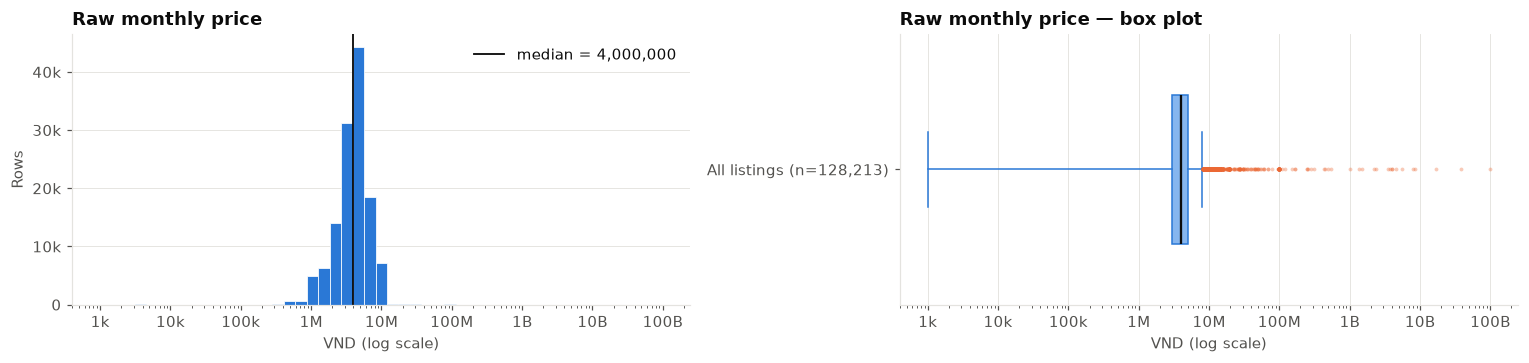

,value
Count,1.282130e+05
Missing,4.281000e+03
Minimum,1.000000e+03
P01,7.812000e+05
P05,1.300000e+06
P25,3.000000e+06
Median,4.000000e+06
P75,5.000000e+06
P95,1.000000e+07
P99,1.000000e+07


In [ ]:
fig, (left, right) = plt.subplots(1, 2, figsize=(14, 3.4))
histogram(
    price_values,
    title="Raw monthly price",
    xlabel="VND (log scale)",
    log_x=True,
    clip_quantile=None,
    ax=left,
)
box_chart(
    {"All listings": price_values},
    title="Raw monthly price — box plot",
    xlabel="VND (log scale)",
    log_x=True,
    ax=right,
)
plt.tight_layout()
plt.show()
distribution_summary(price_values, numeric_data["price_amount"].isna().sum()).to_frame()

### 04.2 Price outliers by source

Box plots per source show whether extremes belong to one crawler.

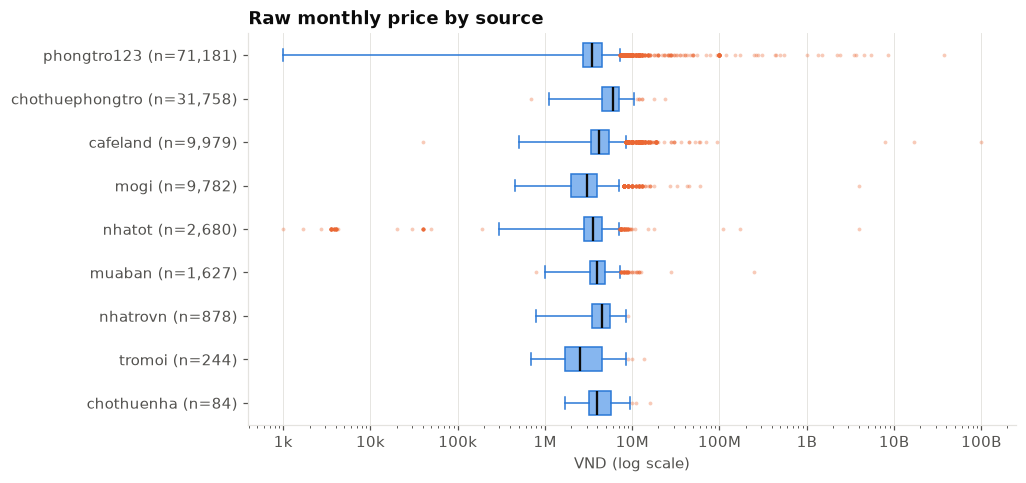

,IQR on raw price
Lower fence,0.00
Upper fence,8000000.00
Rows below fence,0.00
Rows above fence,7475.00
Flagged (%),5.64


,source_code,source_listing_id,price_amount,area_value,title_raw
36968,cafeland,2838449,9.900000e+10,224.5,Phòng trọ: Bán Building MT Hai Bà Trưng P6 Quậ...
104152,phongtro123,tinh-thanh/ho-chi-minh/phong-tro-cho-thue-co-g...,3.800000e+10,25.0,phòng trọ cho thuê có gác giá 3800k quận bình ...
36965,cafeland,2838454,1.700000e+10,100.0,Phòng trọ: Mặt tiền kinh doanh Phan Văn Trị Bì...
68213,phongtro123,627678,8.500000e+09,59.0,CHO THUÊ CĂN HỘ 2PN1WC VINHOMES QUẬN 9
37695,cafeland,2834881,8.000000e+09,60.0,Phòng trọ: Bán Nhà Mặt Tiền 3 Tầng - Kinh Doan...
102101,phongtro123,tinh-thanh/ho-chi-minh/phong-cho-thue-q3-khong...,5.500000e+09,40.0,PHÒNG CHO THUÊ Q3 KHÔNG GIỚI HẠN NGƯỜI Ở
72393,phongtro123,617842,4.500000e+09,30.0,Gác siêu thoáng - dương quảng hàm
24992,mogi,22635973,4.000000e+09,20.0,Cho thuê phòng trọ FULL nội thất ngay ngã tư T...


In [ ]:
source_order = df["source_code"].value_counts().index
box_chart(
    {
        source: price_values[df.loc[price_values.index, "source_code"].eq(source)]
        for source in source_order
    },
    title="Raw monthly price by source",
    xlabel="VND (log scale)",
    log_x=True,
)
plt.show()

price_q1, price_q3, price_iqr, price_lower_fence, price_upper_fence = iqr_fences(price_values)
price_outlier_mask = (numeric_data["price_amount"] < price_lower_fence) | (
    numeric_data["price_amount"] > price_upper_fence
)
display(
    pd.Series(
        {
            "Lower fence": price_lower_fence,
            "Upper fence": price_upper_fence,
            "Rows below fence": (numeric_data["price_amount"] < price_lower_fence).sum(),
            "Rows above fence": (numeric_data["price_amount"] > price_upper_fence).sum(),
            "Flagged (%)": round(price_outlier_mask.mean() * 100, 2),
        },
        name="IQR on raw price",
    ).to_frame()
)
df.nlargest(8, "price_amount")[
    ["source_code", "source_listing_id", "price_amount", "area_value", "title_raw"]
]

### 04.3 Area distribution, box plot & outliers

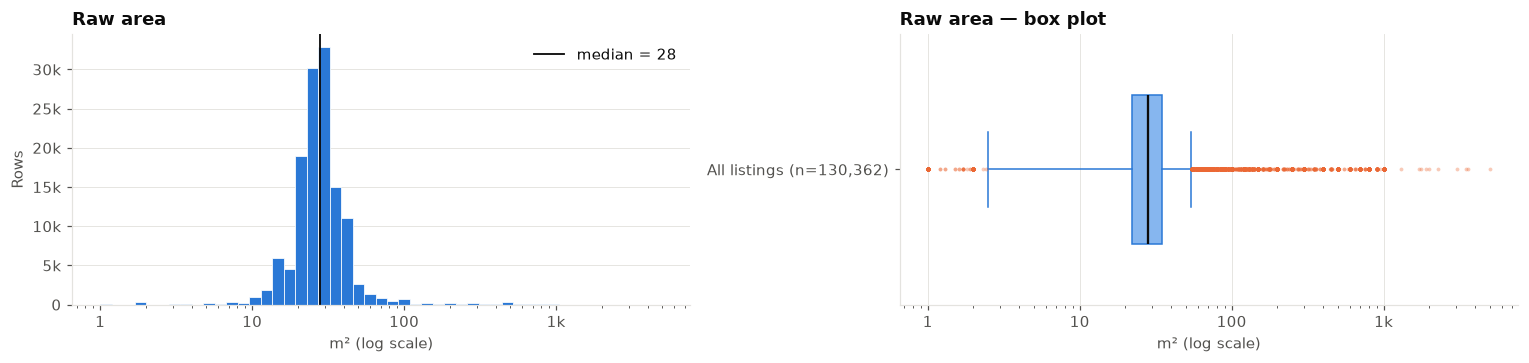

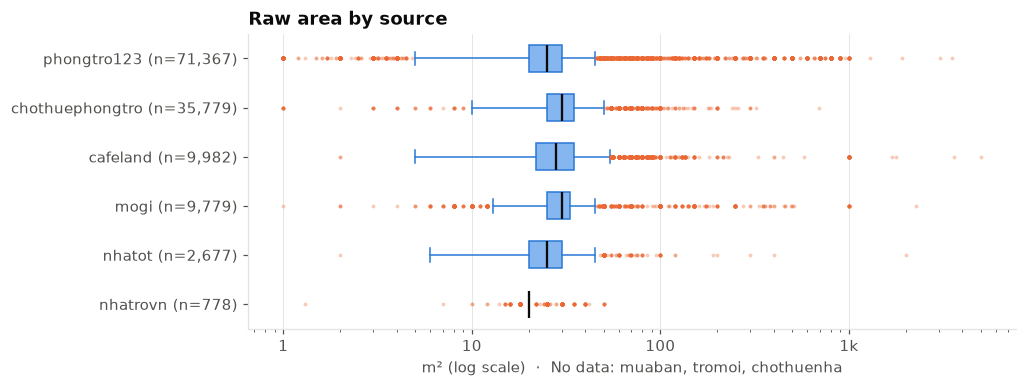

,value
Count,130362.00
Missing,2132.00
Minimum,1.00
P01,9.00
P05,15.00
P25,22.00
Median,28.00
P75,35.00
P95,50.00
P99,135.00


,source_code,source_listing_id,area_value,price_amount,title_raw
1093,phongtro123,713125,1.0,4700000.0,DUPLEX SẴN NỘI THẤT CƠ BẢN · THOÁNG MÁT — ĐƯỜN...
5109,phongtro123,709356,1.0,1600000.0,"Cho Thuê Ktx Tại Số 9 Linh Xuân,Thủ Đức Chỉ Từ..."
6529,phongtro123,707774,1.0,1500000.0,KTX XỊN GIỮA TRUNG TÂM MÀ GIÁ CHỈ TỪ 1M MẤY Si...
6719,phongtro123,621396,1.0,1300000.0,KTX NỮ PHÒNG 4 - 1.3Tr ngay 339 ĐỖ XUÂN HỢP gầ...
22891,cafeland,3038967,5000.0,10000000.0,Phòng trọ: Cho thuê khu nhà nghỉ phòng trọ tại...
39646,cafeland,2791508,3614.0,7500000.0,Cho thuê phòng trọ: Chính Chủ Cho Thuê CHDV 2P...
119976,phongtro123,692084,3500.0,800000.0,Phòng trọ cho thuê giá rẻ tại Nhơn Trạch
98649,phongtro123,tinh-thanh/ho-chi-minh/cho-thue-can-ho%cc%a3-m...,3025.0,2900000.0,"Cho thuê phòng tại 42/36/34E Hoàng Hoa Thám, p..."


In [ ]:
fig, (left, right) = plt.subplots(1, 2, figsize=(14, 3.4))
histogram(
    area_values, title="Raw area", xlabel="m² (log scale)", log_x=True, clip_quantile=None, ax=left
)
box_chart(
    {"All listings": area_values},
    title="Raw area — box plot",
    xlabel="m² (log scale)",
    log_x=True,
    ax=right,
)
plt.tight_layout()
plt.show()
box_chart(
    {
        source: area_values[df.loc[area_values.index, "source_code"].eq(source)]
        for source in source_order
    },
    title="Raw area by source",
    xlabel="m² (log scale)",
    log_x=True,
)
plt.show()

area_q1, area_q3, area_iqr, area_lower_fence, area_upper_fence = iqr_fences(area_values)
area_outlier_mask = (numeric_data["area_value"] < area_lower_fence) | (
    numeric_data["area_value"] > area_upper_fence
)
display(
    pd.concat(
        [
            distribution_summary(area_values, numeric_data["area_value"].isna().sum()),
            pd.Series(
                {
                    "Lower fence": area_lower_fence,
                    "Upper fence": area_upper_fence,
                    "Flagged (%)": round(area_outlier_mask.mean() * 100, 2),
                }
            ),
        ]
    ).to_frame("value")
)
pd.concat([df.nsmallest(4, "area_value"), df.nlargest(4, "area_value")])[
    ["source_code", "source_listing_id", "area_value", "price_amount", "title_raw"]
]

### 04.4 Other numeric fields

In [ ]:
other_numeric_fields = ["active_days", "map_latitude", "map_longitude"]
pd.DataFrame(
    {
        "Available rows": numeric_data[other_numeric_fields].notna().sum(),
        "Minimum": numeric_data[other_numeric_fields].min(),
        "Median": numeric_data[other_numeric_fields].median(),
        "Maximum": numeric_data[other_numeric_fields].max(),
        "Negative values": numeric_data[other_numeric_fields].lt(0).sum(),
    }
)

,Available rows,Minimum,Median,Maximum,Negative values
active_days,132494,0.000000,5.000000,13.000000,0
map_latitude,12849,10.356375,10.798622,11.141580,0
map_longitude,12849,106.449198,106.670151,107.231177,0


### 04.5 Price × area consistency

Price per m² exposes implausible pairs that look normal field by field.

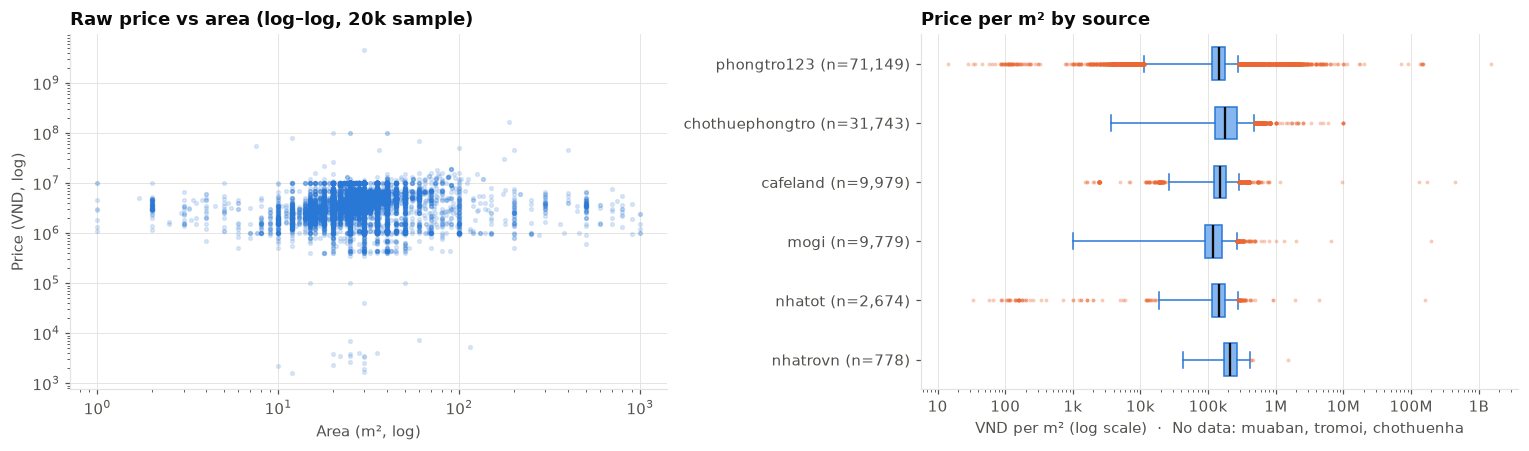

,source_code,source_listing_id,price_amount,area_value,title_raw,price_per_area
104152,phongtro123,tinh-thanh/ho-chi-minh/phong-tro-cho-thue-co-g...,3.800000e+10,25.0,phòng trọ cho thuê có gác giá 3800k quận bình ...,1.520000e+09
36968,cafeland,2838449,9.900000e+10,224.5,Phòng trọ: Bán Building MT Hai Bà Trưng P6 Quậ...,4.409800e+08
24992,mogi,22635973,4.000000e+09,20.0,Cho thuê phòng trọ FULL nội thất ngay ngã tư T...,2.000000e+08
36965,cafeland,2838454,1.700000e+10,100.0,Phòng trọ: Mặt tiền kinh doanh Phan Văn Trị Bì...,1.700000e+08
42279,nhatot,134814654,4.000000e+09,25.0,Mô tả chi tiết,1.600000e+08
72393,phongtro123,617842,4.500000e+09,30.0,Gác siêu thoáng - dương quảng hàm,1.500000e+08
102951,phongtro123,tinh-thanh/ho-chi-minh/phong-16m2-gia-2-400k-c...,2.400000e+09,16.0,Phòng 16m2 giá 2.400k cho 2-3 bạn nữ ở. Tới sa...,1.500000e+08
104097,phongtro123,tinh-thanh/ho-chi-minh/cho-thue-nha-tro%cc%a3-...,3.700000e+09,25.0,Cho thuê nhà trọ giá 3tr7 tại nguyễn thị...,1.480000e+08


In [ ]:
price_area_mask = numeric_data["price_amount"].gt(0) & numeric_data["area_value"].gt(0)
price_area_audit = df.loc[
    price_area_mask, ["source_code", "source_listing_id", "price_amount", "area_value", "title_raw"]
].copy()
price_area_audit["price_per_area"] = pd.to_numeric(
    price_area_audit["price_amount"]
) / pd.to_numeric(price_area_audit["area_value"])

sample = price_area_audit.sample(min(20000, len(price_area_audit)), random_state=42)
fig, (left, right) = plt.subplots(1, 2, figsize=(14, 4.2))
left.scatter(sample["area_value"], sample["price_amount"], s=6, alpha=0.15, color=CATEGORICAL[0])
left.set(
    xscale="log",
    yscale="log",
    title="Raw price vs area (log–log, 20k sample)",
    xlabel="Area (m², log)",
    ylabel="Price (VND, log)",
)
left.grid(axis="y")
box_chart(
    {
        source: price_area_audit.loc[price_area_audit.source_code.eq(source), "price_per_area"]
        for source in source_order
    },
    title="Price per m² by source",
    xlabel="VND per m² (log scale)",
    log_x=True,
    ax=right,
)
plt.tight_layout()
plt.show()
price_area_audit.nlargest(8, "price_per_area")

### 04.6 Outlier detection rules compared

Raw IQR on a skewed variable flags many ordinary rents; IQR on log values and percentile fences are less aggressive.

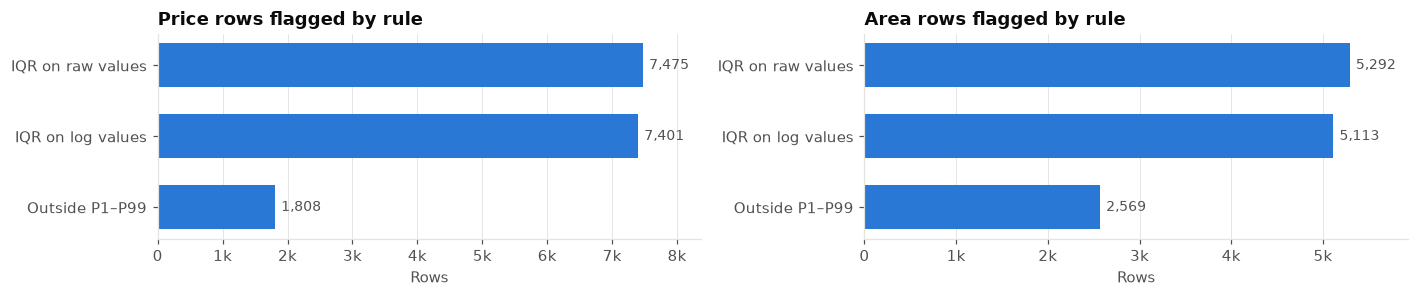

In [ ]:
def flag_counts(values):
    values = values[values > 0]
    _, _, _, low, high = iqr_fences(values)
    log_values = np.log(values)
    _, _, _, log_low, log_high = iqr_fences(log_values)
    p01, p99 = values.quantile([0.01, 0.99])
    return pd.Series(
        {
            "IQR on raw values": int(((values < low) | (values > high)).sum()),
            "IQR on log values": int(((log_values < log_low) | (log_values > log_high)).sum()),
            "Outside P1–P99": int(((values < p01) | (values > p99)).sum()),
        }
    )


detection_rules = pd.DataFrame(
    {"Price": flag_counts(price_values), "Area": flag_counts(area_values)}
)
fig, (left, right) = plt.subplots(1, 2, figsize=(13, 2.8))
bar_chart(
    detection_rules["Price"], sort=False, title="Price rows flagged by rule", xlabel="Rows", ax=left
)
bar_chart(
    detection_rules["Area"], sort=False, title="Area rows flagged by rule", xlabel="Rows", ax=right
)
plt.tight_layout()
plt.show()

### 04.7 Outlier treatment options compared (on a copy)

Remove, winsorize (cap at P1/P99) or keep-and-flag — and what each does to the distribution.

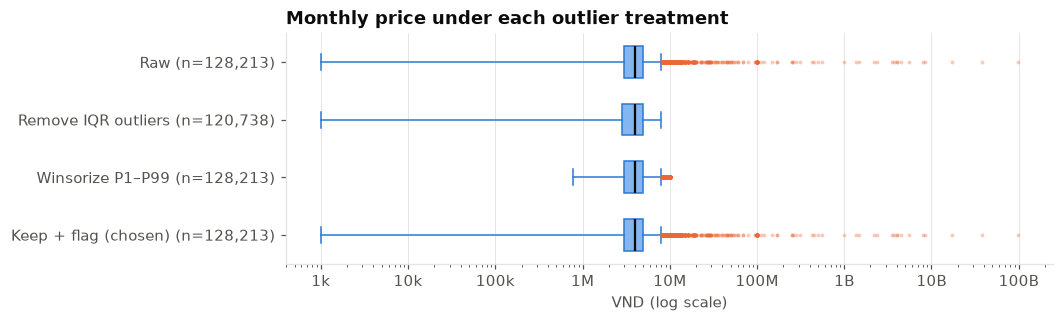

,Rows,Mean,Median,Std,Max
Raw,128213.0,5.950048e+06,4000000.0,3.033024e+08,9.900000e+10
Remove IQR outliers,120738.0,3.939813e+06,4000000.0,1.606678e+06,8.000000e+06
Winsorize P1–P99,128213.0,4.290460e+06,4000000.0,2.089855e+06,1.000000e+07
Keep + flag (chosen),128213.0,5.950048e+06,4000000.0,3.033024e+08,9.900000e+10


Removing IQR outliers drops **7,475** listings, including genuine high-end rentals; winsorizing changes real values. RoomBeacon keeps every value, records an outlier flag, and lets the model use only rows whose price is trusted.

In [ ]:
df_before = df.copy(deep=True)
positive_price = price_values[price_values > 0]
p01, p99 = positive_price.quantile([0.01, 0.99])
treatments = {
    "Raw": positive_price,
    "Remove IQR outliers": positive_price[
        (positive_price >= price_lower_fence) & (positive_price <= price_upper_fence)
    ],
    "Winsorize P1–P99": positive_price.clip(p01, p99),
    "Keep + flag (chosen)": positive_price,
}
box_chart(
    treatments,
    title="Monthly price under each outlier treatment",
    xlabel="VND (log scale)",
    log_x=True,
)
plt.show()
display(
    pd.DataFrame(
        {
            name: {
                "Rows": len(v),
                "Mean": v.mean(),
                "Median": v.median(),
                "Std": v.std(),
                "Max": v.max(),
            }
            for name, v in treatments.items()
        }
    ).T
)
pd.testing.assert_frame_equal(df, df_before)  # the simulation did not modify df
display(
    Markdown(
        f"Removing IQR outliers drops **{len(positive_price) - len(treatments['Remove IQR outliers']):,}** listings, "
        "including genuine high-end rentals; winsorizing changes real values. RoomBeacon keeps every value, records an "
        "outlier flag, and lets the model use only rows whose price is trusted."
    )
)

### 04.8 Outlier treatment decision

Applied in Notebook 02 (Silver) and Notebook 04 (model population).

In [ ]:
pd.DataFrame(
    [
        [
            "Impossible values (negative, zero, out-of-range coordinates)",
            "Invalid → clean value null + status",
            "Cannot be a real listing",
        ],
        [
            "Statistical outliers (price, area)",
            "Keep; `numeric_outlier_status` flag (IQR 1.5×)",
            "Rare ≠ wrong; deleting would bias the market view",
        ],
        [
            "Implausible price × area pairs",
            "Keep; `price_area_quality_status` review flag",
            "Each field looks normal; only the ratio is suspicious",
        ],
        [
            "Model training",
            "Only rows with trusted price evidence and supported semantics (Notebook 04)",
            "Robust to tails without editing data",
        ],
        ["Charts", "Log axes or a stated P99 display cap", "Readability only; no value is changed"],
    ],
    columns=["Case", "Treatment", "Why"],
)

,Case,Treatment,Why
0,"Impossible values (negative, zero, out-of-rang...",Invalid → clean value null + status,Cannot be a real listing
1,"Statistical outliers (price, area)",Keep; `numeric_outlier_status` flag (IQR 1.5×),Rare ≠ wrong; deleting would bias the market view
2,Implausible price × area pairs,Keep; `price_area_quality_status` review flag,Each field looks normal; only the ratio is sus...
3,Model training,Only rows with trusted price evidence and supp...,Robust to tails without editing data
4,Charts,Log axes or a stated P99 display cap,Readability only; no value is changed


## 05. Text Quality Analysis

> **Why:** Detect representation and length anomalies in text without modifying it.

### 05.1 Text representation issues

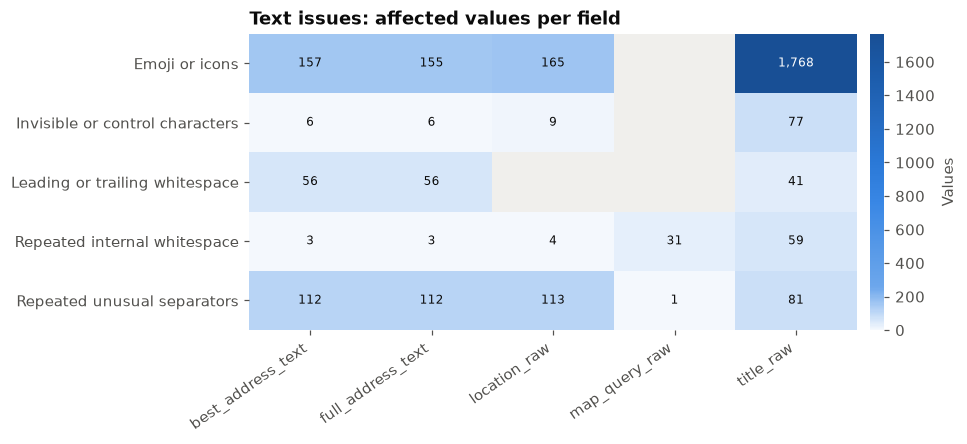

In [ ]:
text_fields = [
    "title_raw",
    "full_address_text",
    "location_raw",
    "map_query_raw",
    "best_address_text",
]
text_checks = {
    "Empty or whitespace only": r"^\s*$",
    "Leading or trailing whitespace": r"^\s|\s$",
    "Repeated internal whitespace": r"\s{2,}",
    "Emoji or icons": r"[\U0001F300-\U0001FAFF\u2600-\u27BF]",
    "Invisible or control characters": r"[\u200B-\u200D\u2060\uFEFF\x00-\x08\x0B\x0C\x0E-\x1F\x7F]",
    "Repeated unusual separators": r"[|;_-]{2,}",
}
text_quality = pd.DataFrame(
    [
        {
            "Text field": field,
            "Quality issue": issue,
            "Affected rows": df[field]
            .astype("string")
            .str.contains(pattern, regex=True, na=False)
            .sum(),
        }
        for field in text_fields
        for issue, pattern in text_checks.items()
    ]
)
text_quality = text_quality.loc[text_quality["Affected rows"] > 0]
text_issue_rows = (
    df[text_fields]
    .apply(
        lambda column: column.astype("string").str.contains(
            "|".join(text_checks.values()), regex=True, na=False
        )
    )
    .any(axis=1)
)
heatmap(
    text_quality.pivot(index="Quality issue", columns="Text field", values="Affected rows"),
    title="Text issues: affected values per field",
    fmt="{:,.0f}",
    label="Values",
)
plt.show()

### 05.2 Text length

Very short or very long titles/addresses deserve review.

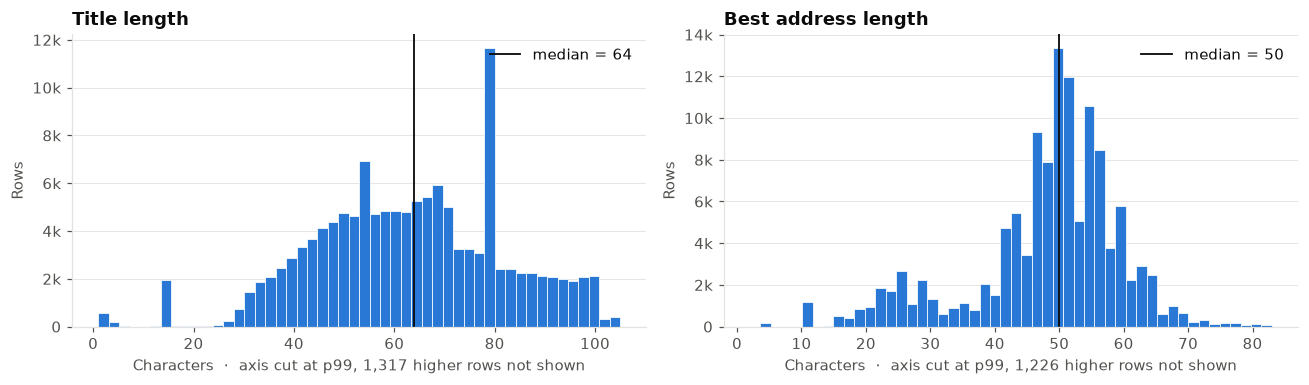

,count,mean,std,min,1%,5%,50%,95%,99%,max
title_raw,131971.0,63.610574,19.525006,1.0,14.0,34.0,64.0,96.0,105.0,172.0
best_address_text,124377.0,49.804063,27.832639,2.0,11.0,24.0,50.0,64.0,83.0,500.0


In [ ]:
text_lengths = pd.DataFrame(
    {field: df[field].astype("string").str.len() for field in ["title_raw", "best_address_text"]}
)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
histogram(text_lengths["title_raw"], title="Title length", xlabel="Characters", ax=axes[0])
histogram(
    text_lengths["best_address_text"], title="Best address length", xlabel="Characters", ax=axes[1]
)
plt.tight_layout()
plt.show()
text_lengths.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T

## 06. Address & Location Quality

> **Why:** Audit address coverage, parser output, administrative mapping and coordinates.

### 06.1 Address and location coverage

Parser columns are diagnostic only (temporary `location_audit` frame).

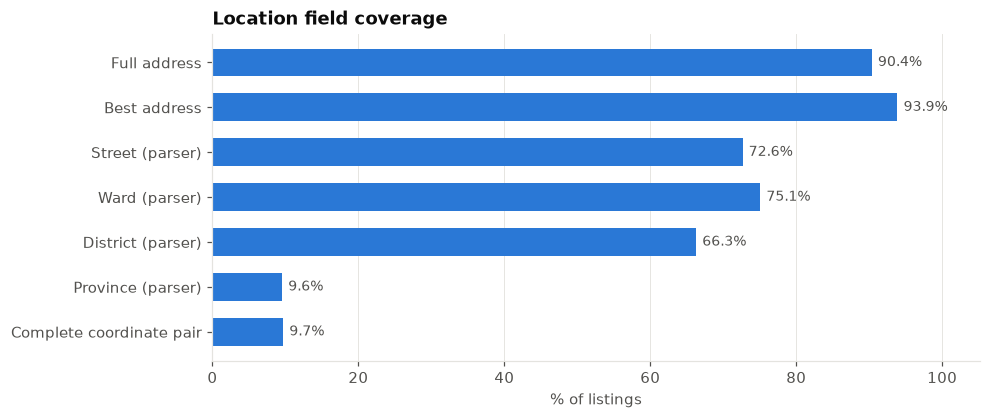

In [ ]:
location_audit = apply_address_parsing(
    df[["rental_post_id", "source_code", "best_address_text"]].copy(), "best_address_text"
)
location_audit = apply_ward_mapping(
    location_audit, "ward_text_extracted", "district_text_extracted"
)

location_coverage = pd.Series(
    {
        "Full address": (~missing_flags["full_address_text"]).mean() * 100,
        "Best address": (~missing_flags["best_address_text"]).mean() * 100,
        "Street (parser)": location_audit["street_text_extracted"].notna().mean() * 100,
        "Ward (parser)": location_audit["ward_text_extracted"].notna().mean() * 100,
        "District (parser)": location_audit["district_text_extracted"].notna().mean() * 100,
        "Province (parser)": location_audit["province_text_extracted"].notna().mean() * 100,
        "Complete coordinate pair": (
            (~missing_flags["map_latitude"]) & (~missing_flags["map_longitude"])
        ).mean()
        * 100,
    }
)
bar_chart(
    location_coverage,
    title="Location field coverage",
    xlabel="% of listings",
    sort=False,
    fmt="{:.1f}%",
)
plt.show()

### 06.2 Address length outliers

In [ ]:
address_lengths = df["best_address_text"].astype("string").str.len()
_, _, _, address_lower_fence, address_upper_fence = iqr_fences(address_lengths.dropna())
outside = (address_lengths < address_lower_fence) | (address_lengths > address_upper_fence)
display(
    pd.Series(
        {
            "Lower fence": address_lower_fence,
            "Upper fence": address_upper_fence,
            "Rows outside fences": int(outside.sum()),
        },
        name="value",
    ).to_frame()
)
pd.concat([df.loc[address_lengths.nsmallest(5).index], df.loc[address_lengths.nlargest(5).index]])[
    ["source_code", "best_address_text"]
]

,value
Lower fence,27.5
Upper fence,71.5
Rows outside fences,13906.0


,source_code,best_address_text
32455,nhatot,xã
2339,tromoi,386
2340,tromoi,386
8014,nhatot,null
8016,nhatot,null
20,mogi,"23 Nguyễn Kim, Phường Chợ Lớn, Quận 5, Hồ Chí ..."
87,mogi,"306 Gò Dầu, P Tân Quý, Q Tân Phú - Gần Tân Quý..."
93,mogi,"380 Xô Viết Nghệ Tĩnh, Phường 25, Quận Bình Th..."
97,mogi,"350 Huỳnh Tấn Phát, Q.7 - Xung quanh nhà có nh..."
103,mogi,Trung tâm quận Bình Thạnh số nhà 549 Đường Xô ...


### 06.3 Address structural consistency

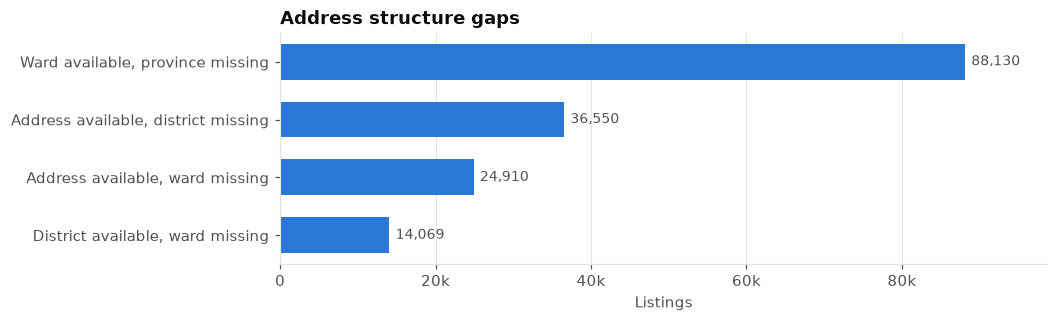

In [ ]:
has_address = ~missing_flags["best_address_text"]
address_structure_summary = pd.Series(
    {
        "Address available, ward missing": (
            has_address & location_audit["ward_text_extracted"].isna()
        ).sum(),
        "Address available, district missing": (
            has_address & location_audit["district_text_extracted"].isna()
        ).sum(),
        "Ward available, province missing": (
            location_audit["ward_text_extracted"].notna()
            & location_audit["province_text_extracted"].isna()
        ).sum(),
        "District available, ward missing": (
            location_audit["district_text_extracted"].notna()
            & location_audit["ward_text_extracted"].isna()
        ).sum(),
    }
)
bar_chart(address_structure_summary, title="Address structure gaps", xlabel="Listings")
plt.show()

### 06.4 Administrative unit migration audit

Status of mapping extracted wards to the post-merger reference (`WARD_MAPPING`, internal). Counts need human validation for parser edge cases.

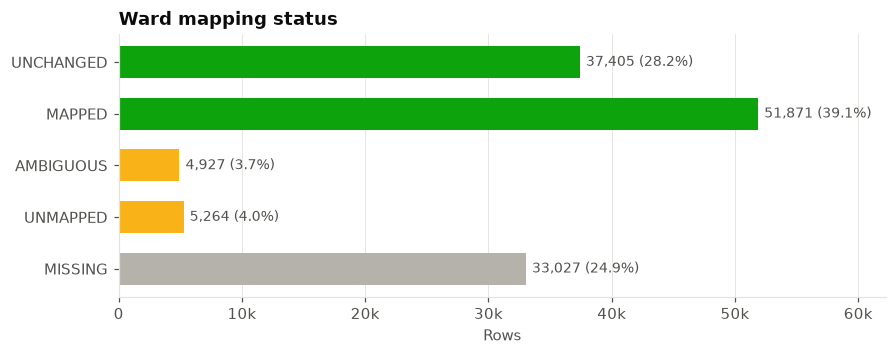

,Unresolved rows,Unresolved (%)
source_code,,
cafeland,10,0.10
chothuenha,10,11.90
chothuephongtro,5799,16.20
mogi,2164,22.12
muaban,308,18.91
nhatot,495,18.45
nhatrovn,291,33.14
phongtro123,1078,1.51
tromoi,36,14.12


In [ ]:
administrative_status = (
    location_audit["ward_mapping_status"]
    .value_counts(dropna=False)
    .reindex(["UNCHANGED", "MAPPED", "AMBIGUOUS", "UNMAPPED", "MISSING"], fill_value=0)
)
status_chart(administrative_status, tiers=STATUS_TIERS, title="Ward mapping status")
plt.show()
unresolved_by_source = (
    location_audit.assign(
        unresolved=location_audit["ward_mapping_status"].isin(["AMBIGUOUS", "UNMAPPED"])
    )
    .groupby("source_code")["unresolved"]
    .agg(**{"Unresolved rows": "sum", "Unresolved (%)": lambda x: round(x.mean() * 100, 2)})
)
unresolved_by_source

### 06.5 Coordinate completeness

In [ ]:
has_latitude = ~missing_flags["map_latitude"]
has_longitude = ~missing_flags["map_longitude"]
has_coordinates = has_latitude & has_longitude
pd.Series(
    {
        "Complete coordinate pair": has_coordinates.sum(),
        "Only latitude": (has_latitude & ~has_longitude).sum(),
        "Only longitude": (~has_latitude & has_longitude).sum(),
        "Address available, coordinates missing": (has_address & ~has_coordinates).sum(),
        "Coordinates available, address missing": (~has_address & has_coordinates).sum(),
    },
    name="Rows",
).to_frame()

,Rows
Complete coordinate pair,12849
Only latitude,0
Only longitude,0
"Address available, coordinates missing",111528
"Coordinates available, address missing",0


## 07. Source-Level Data Quality

> **Why:** Compare quality problems across sources (source size is not market share).

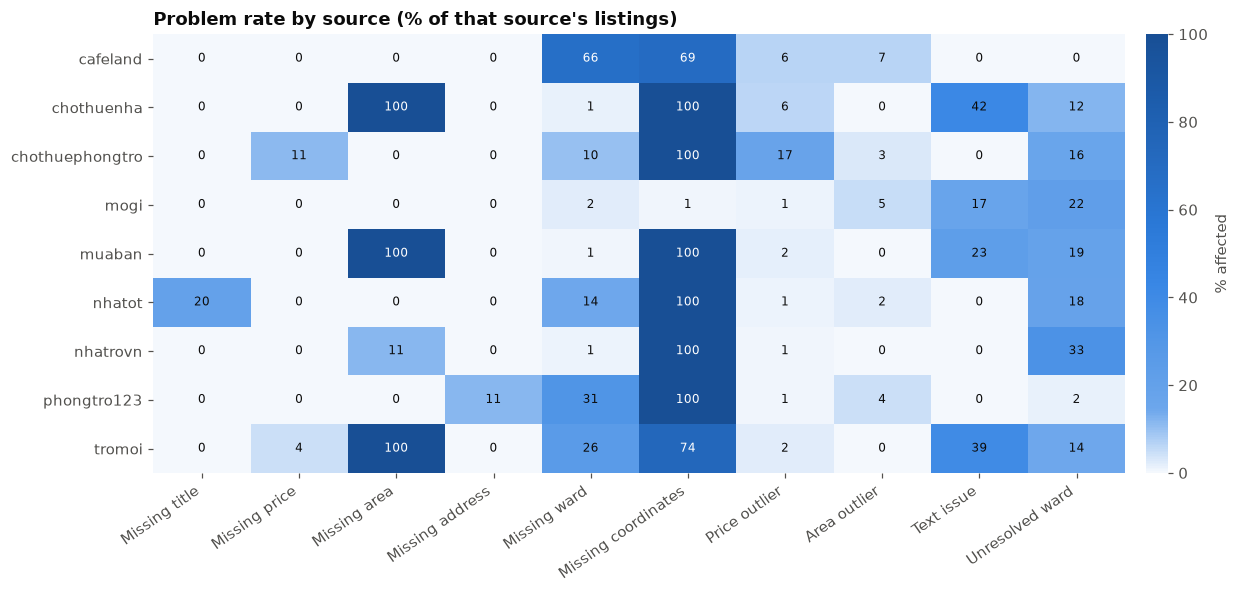

In [ ]:
source_quality_flags = pd.DataFrame(
    {
        "source_code": df["source_code"],
        "Missing title": missing_flags["title_raw"],
        "Missing price": missing_flags["price_amount"],
        "Missing area": missing_flags["area_value"],
        "Missing address": missing_flags["best_address_text"],
        "Missing ward": location_audit["ward_text_extracted"].isna(),
        "Missing coordinates": ~has_coordinates,
        "Price outlier": price_outlier_mask.fillna(False),
        "Area outlier": area_outlier_mask.fillna(False),
        "Text issue": text_issue_rows,
        "Unresolved ward": location_audit["ward_mapping_status"].isin(["AMBIGUOUS", "UNMAPPED"]),
    }
)
source_quality = source_quality_flags.groupby("source_code").mean().mul(100).round(1)
heatmap(
    source_quality,
    title="Problem rate by source (% of that source's listings)",
    vmax=100,
    label="% affected",
)
plt.show()

## 08. Cross-variable Relationship Analysis

> **Why:** Inspect relationships, source effects and suspicious combinations. Results are diagnostic — not market rankings or causal claims.

### 08.1 Price × Area Relationship

Pearson measures linear association; Spearman measures monotonic association and is robust to skew.

In [ ]:
MIN_LOCATION_SAMPLE = 50
MIN_LOCATION_SOURCE_SAMPLE = 30

relationship_audit = df[
    [
        "rental_post_id",
        "source_code",
        "source_listing_id",
        "title_raw",
        "price_amount",
        "area_value",
        "best_address_text",
        "map_latitude",
        "map_longitude",
    ]
].copy()
relationship_audit = relationship_audit.join(
    location_audit[
        [
            "parse_status",
            "ward_text_extracted",
            "district_text_extracted",
            "ward_current",
            "ward_mapping_status",
        ]
    ]
)
relationship_audit["Price"] = pd.to_numeric(relationship_audit["price_amount"], errors="coerce")
relationship_audit["Area"] = pd.to_numeric(relationship_audit["area_value"], errors="coerce")
relationship_audit["Price Outlier"] = price_outlier_mask.fillna(False)
relationship_audit["Area Outlier"] = area_outlier_mask.fillna(False)
relationship_audit["Price per Area"] = (
    relationship_audit["Price"]
    .div(relationship_audit["Area"])
    .where(relationship_audit["Price"].gt(0) & relationship_audit["Area"].gt(0))
)
positive_pair = relationship_audit.loc[
    relationship_audit["Price"].gt(0) & relationship_audit["Area"].gt(0)
].copy()

relationship_correlation = pd.DataFrame(
    {
        "Metric": ["Listings", "Pearson Correlation", "Spearman Correlation"],
        "Value": [
            len(positive_pair),
            positive_pair["Price"].corr(positive_pair["Area"], method="pearson"),
            positive_pair["Price"].corr(positive_pair["Area"], method="spearman"),
        ],
    }
)
display(relationship_correlation)
price_limits = positive_pair["Price"].quantile([0.01, 0.99])

,Metric,Value
0,Listings,126102.000000
1,Pearson Correlation,0.010679
2,Spearman Correlation,0.304297


Price by area band (bands are temporary EDA groupings):

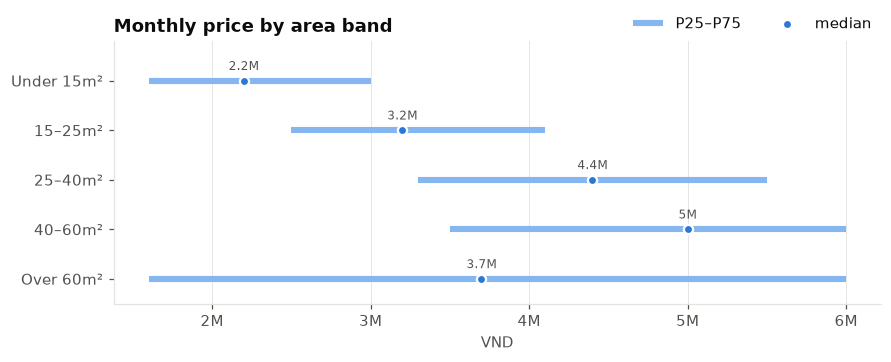

,Listings,p25,median,p75
Area band,,,,
Under 15m²,4778,1600000.0,2200000.0,3000000.0
15–25m²,30867,2500000.0,3200000.0,4100000.0
25–40m²,73316,3300000.0,4400000.0,5500000.0
40–60m²,12810,3500000.0,5000000.0,6000000.0
Over 60m²,4331,1600000.0,3700000.0,6000000.0


In [ ]:
area_labels = ["Under 15m²", "15–25m²", "25–40m²", "40–60m²", "Over 60m²"]
positive_pair["Area band"] = pd.cut(
    positive_pair["Area"], [0, 15, 25, 40, 60, np.inf], labels=area_labels, right=False
)
area_band_price = positive_pair.groupby("Area band", observed=True)["Price"].agg(
    Listings="size", p25=lambda x: x.quantile(0.25), median="median", p75=lambda x: x.quantile(0.75)
)
range_chart(
    area_band_price,
    low="p25",
    mid="median",
    high="p75",
    title="Monthly price by area band",
    xlabel="VND",
)
plt.show()
area_band_price

### 08.2 Location × Price

Only resolved current wards with at least `MIN_LOCATION_SAMPLE` valid observations; the 15 largest wards are shown with their sample size.

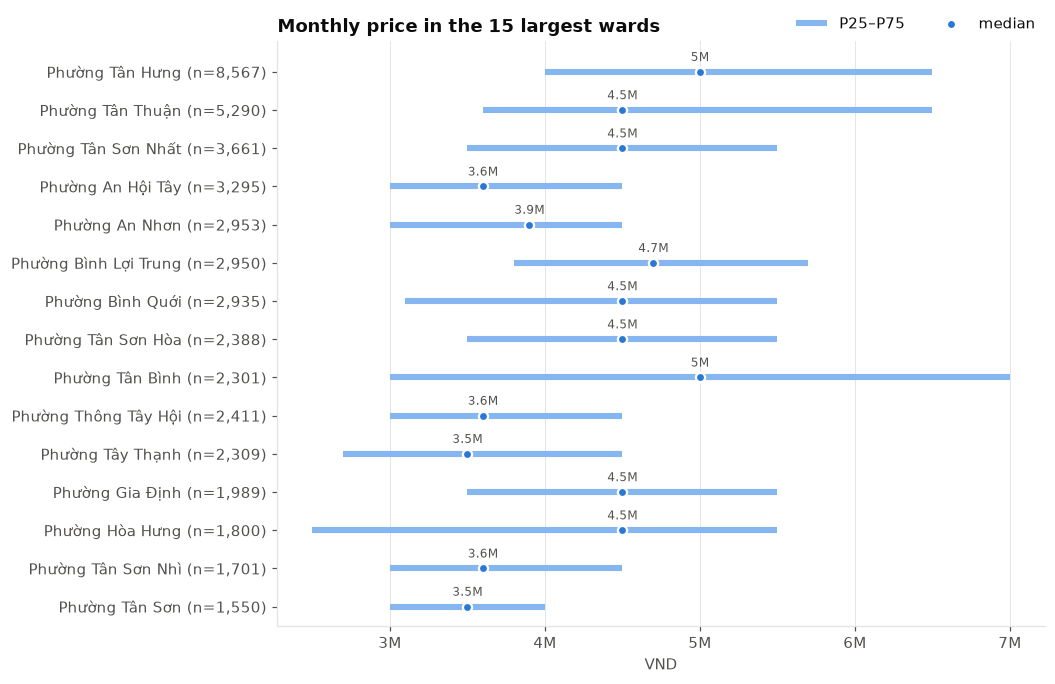

In [ ]:
ward_base = relationship_audit.dropna(subset=["ward_current"]).copy()


def ward_profile(value, valid_label):
    table = ward_base.groupby("ward_current").agg(
        Listings=("rental_post_id", "size"),
        **{
            valid_label: (value, "count"),
            "p25": (value, lambda x: x.quantile(0.25)),
            "median": (value, "median"),
            "p75": (value, lambda x: x.quantile(0.75)),
        },
    )
    table = table.loc[table[valid_label] >= MIN_LOCATION_SAMPLE].sort_values(
        "Listings", ascending=False
    )
    table.index = [f"{ward} (n={int(n):,})" for ward, n in zip(table.index, table[valid_label])]
    return table


location_price = ward_profile("Price", "Valid Price Records")
range_chart(
    location_price.head(15),
    low="p25",
    mid="median",
    high="p75",
    title="Monthly price in the 15 largest wards",
    xlabel="VND",
)
plt.show()

### 08.3 Location × Area

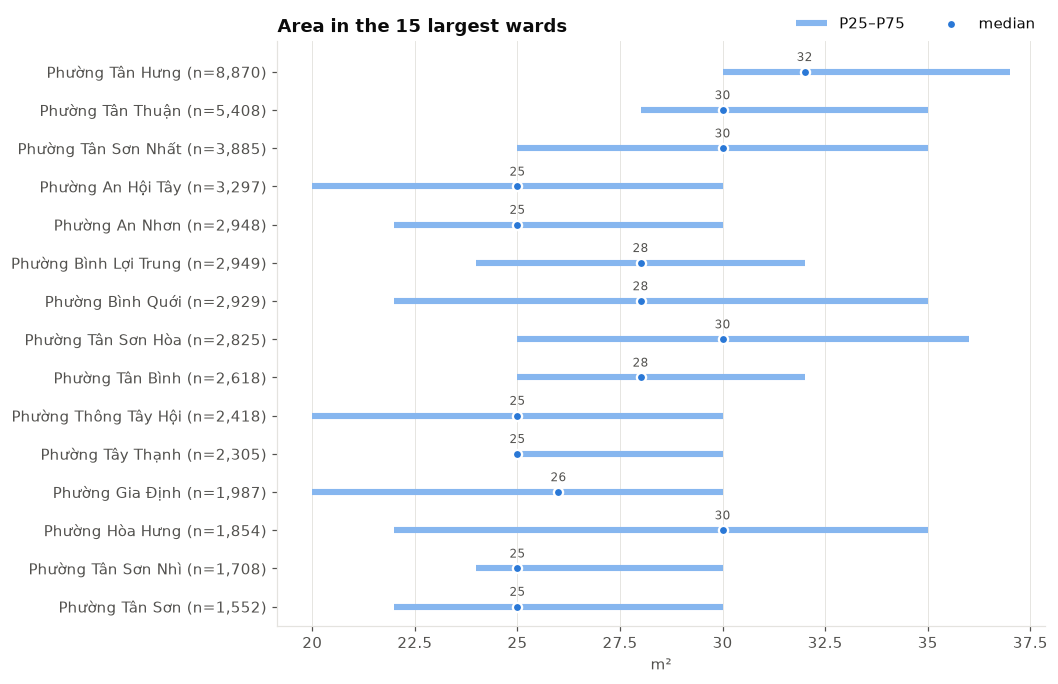

In [ ]:
location_area = ward_profile("Area", "Valid Area Records")
range_chart(
    location_area.head(15),
    low="p25",
    mid="median",
    high="p75",
    title="Area in the 15 largest wards",
    xlabel="m²",
)
plt.show()

### 08.4 Location × Price per Area

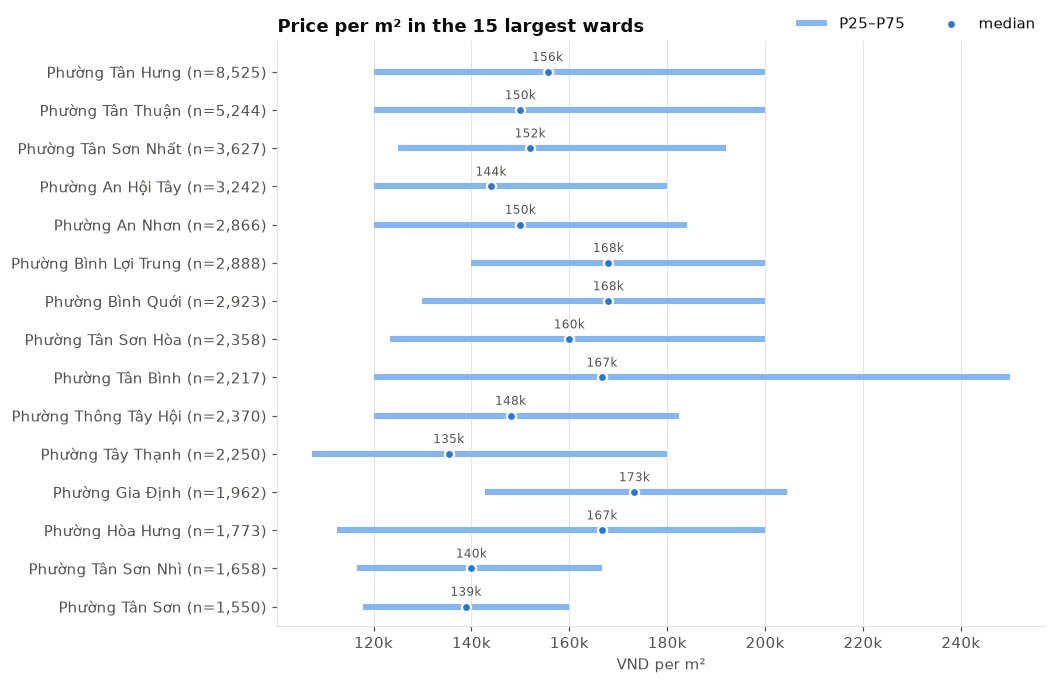

In [ ]:
location_price_area = ward_profile("Price per Area", "Valid Price-per-Area Records")
range_chart(
    location_price_area.head(15),
    low="p25",
    mid="median",
    high="p75",
    title="Price per m² in the 15 largest wards",
    xlabel="VND per m²",
)
plt.show()

### 08.5 Source × Price

Source differences describe crawler representation, not market activity.

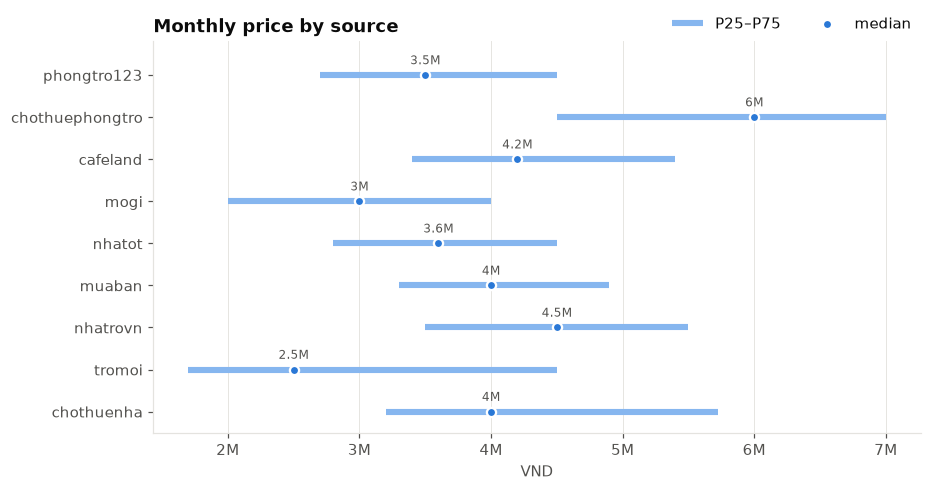

In [ ]:
def source_profile(value, valid_label):
    table = relationship_audit.groupby("source_code").agg(
        **{
            valid_label: (value, "count"),
            "p25": (value, lambda x: x.quantile(0.25)),
            "median": (value, "median"),
            "p75": (value, lambda x: x.quantile(0.75)),
        }
    )
    return table.loc[table[valid_label] >= MIN_LOCATION_SAMPLE].sort_values(
        valid_label, ascending=False
    )


source_price = source_profile("Price", "Valid Price Records")
range_chart(
    source_price, low="p25", mid="median", high="p75", title="Monthly price by source", xlabel="VND"
)
plt.show()

### 08.6 Source × Area

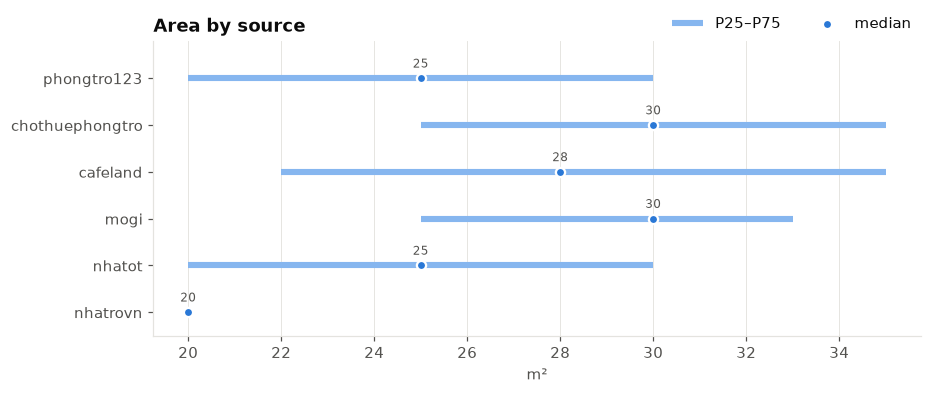

In [ ]:
source_area = source_profile("Area", "Valid Area Records")
range_chart(source_area, low="p25", mid="median", high="p75", title="Area by source", xlabel="m²")
plt.show()

### 08.7 Source × Location

Which sources supply each high-volume ward?

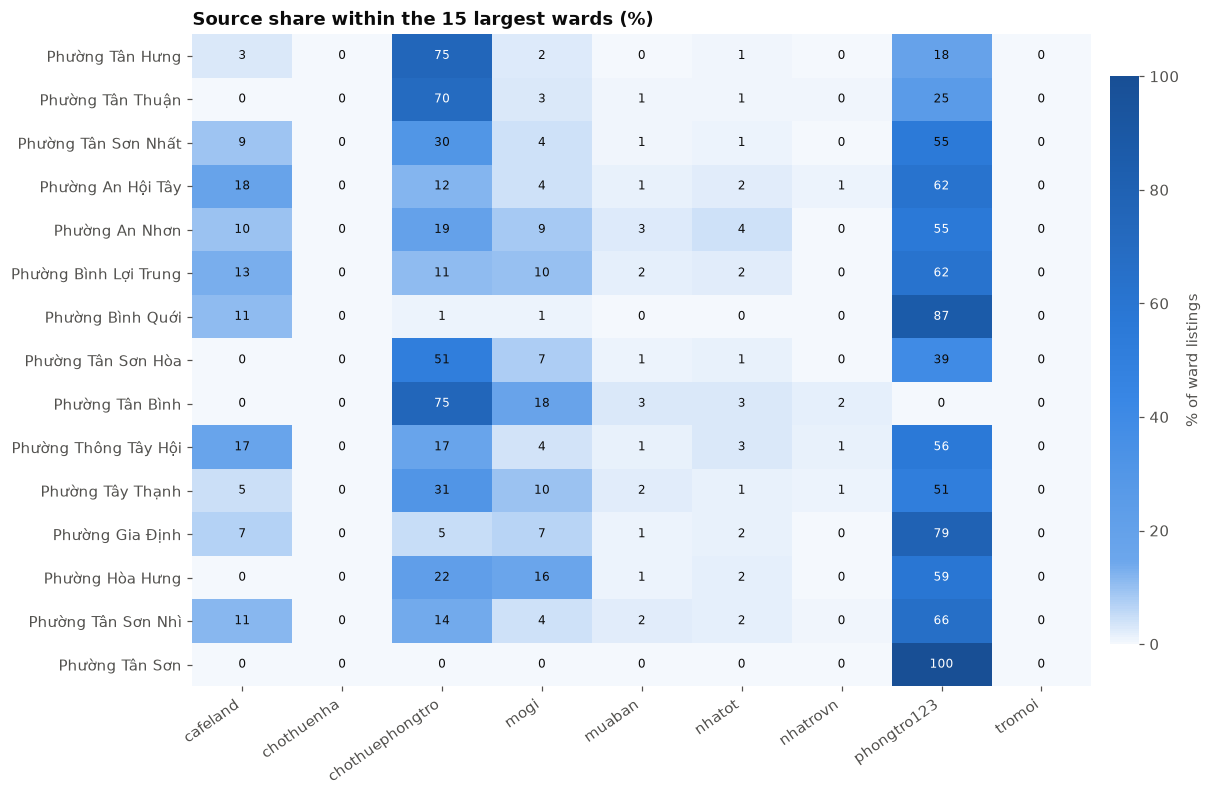

In [ ]:
ward_source_counts = (
    ward_base.groupby(["ward_current", "source_code"]).size().rename("Listings").reset_index()
)
ward_source_summary = (
    ward_source_counts.groupby("ward_current")
    .agg(Listings=("Listings", "sum"), **{"Number of sources": ("source_code", "nunique")})
    .query("Listings >= @MIN_LOCATION_SAMPLE")
    .sort_values("Listings", ascending=False)
)
heatmap_wards = ward_source_summary.head(15).index
ward_source_share = (
    ward_source_counts.loc[ward_source_counts["ward_current"].isin(heatmap_wards)]
    .pivot(index="ward_current", columns="source_code", values="Listings")
    .fillna(0)
    .reindex(heatmap_wards)
)
ward_source_share = ward_source_share.div(ward_source_share.sum(axis=1), axis=0).mul(100)
heatmap(
    ward_source_share,
    title="Source share within the 15 largest wards (%)",
    vmax=100,
    label="% of ward listings",
)
plt.show()

### 08.8 Source × Location × Price

Groups below `MIN_LOCATION_SOURCE_SAMPLE` stay blank; zero is never imputed.

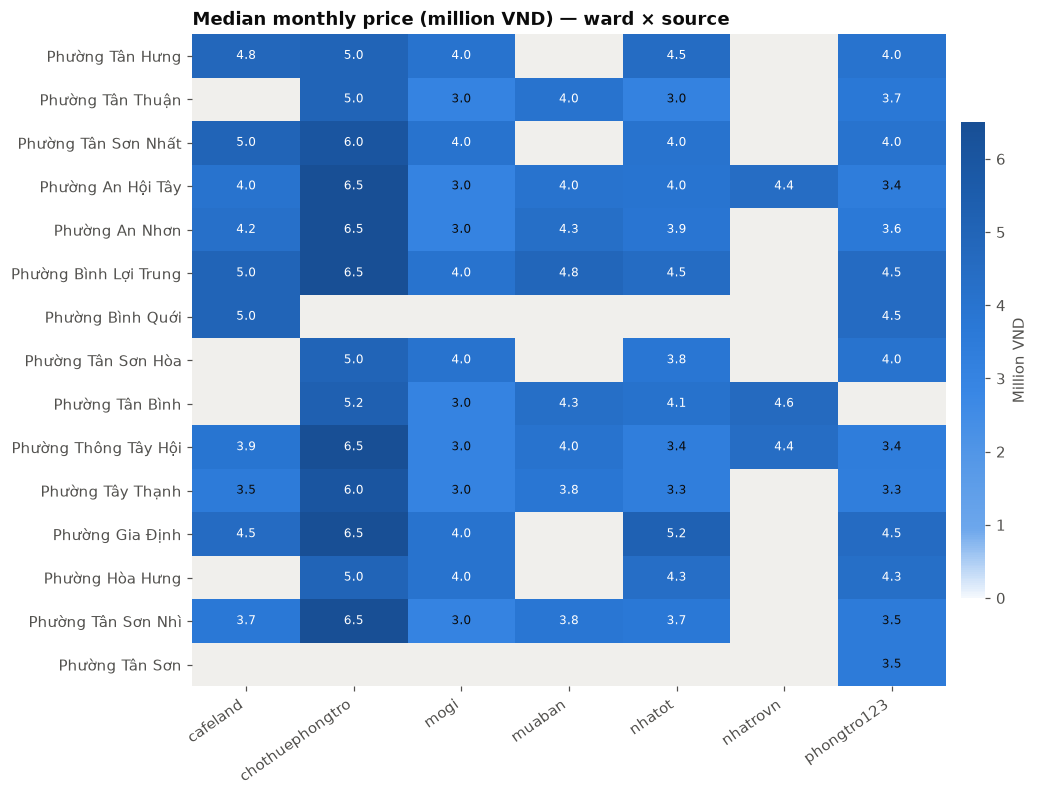

In [ ]:
ward_source_price = (
    ward_base.groupby(["ward_current", "source_code"])
    .agg(
        Listings=("rental_post_id", "size"),
        **{"Valid Price Records": ("Price", "count"), "Median Price": ("Price", "median")}
    )
    .query("`Valid Price Records` >= @MIN_LOCATION_SOURCE_SAMPLE")
    .reset_index()
)
price_heatmap = (
    ward_source_price.loc[ward_source_price["ward_current"].isin(heatmap_wards)]
    .pivot(index="ward_current", columns="source_code", values="Median Price")
    .reindex(heatmap_wards)
    / 1e6
)
heatmap(
    price_heatmap,
    title="Median monthly price (million VND) — ward × source",
    fmt="{:.1f}",
    label="Million VND",
)
plt.show()

### 08.9 Address Resolution × Critical Fields

Does a resolved address go together with price, area and coordinates?

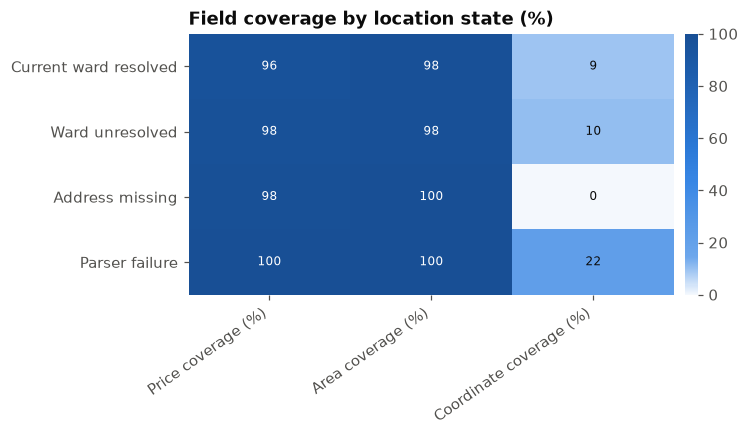

In [ ]:
address_available = (
    relationship_audit["best_address_text"].astype("string").str.strip().replace("", pd.NA).notna()
)
location_state = pd.Series("Ward unresolved", index=df.index, dtype="string")
location_state.loc[relationship_audit["ward_current"].notna()] = "Current ward resolved"
location_state.loc[relationship_audit["parse_status"].isin(["UNRECOGNIZED_FORMAT", "MISSING"])] = (
    "Parser failure"
)
location_state.loc[~address_available] = "Address missing"
address_resolution_critical = (
    relationship_audit.assign(
        **{"Location state": location_state, "Coordinate available": has_coordinates}
    )
    .groupby("Location state")
    .agg(
        Listings=("rental_post_id", "size"),
        **{
            "Price coverage (%)": ("Price", lambda x: x.notna().mean() * 100),
            "Area coverage (%)": ("Area", lambda x: x.notna().mean() * 100),
            "Coordinate coverage (%)": ("Coordinate available", lambda x: x.mean() * 100),
        },
    )
    .sort_values("Listings", ascending=False)
)
heatmap(
    address_resolution_critical.drop(columns="Listings"),
    title="Field coverage by location state (%)",
    vmax=100,
)
plt.show()

### 08.10 Price × Area × Location

Each dot is a ward with at least `MIN_LOCATION_SAMPLE` listings; dot size = listings. Medians cluster on round values (25/28/30 m², 3–5 M VND) because sellers post rounded numbers.

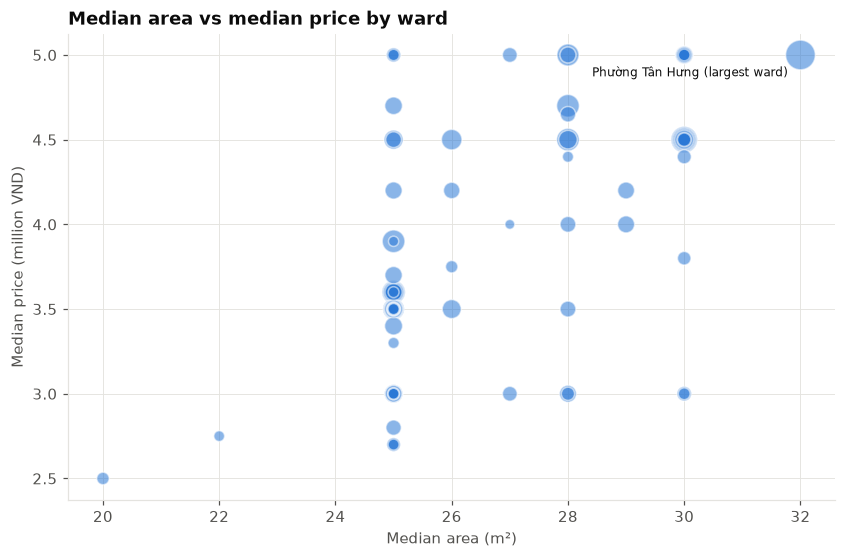

In [ ]:
location_relationship = (
    ward_base.groupby("ward_current")
    .agg(
        Listings=("rental_post_id", "size"),
        **{
            "Valid Price Records": ("Price", "count"),
            "Valid Area Records": ("Area", "count"),
            "Median Price": ("Price", "median"),
            "Median Area": ("Area", "median"),
        },
    )
    .query(
        "`Valid Price Records` >= @MIN_LOCATION_SAMPLE and `Valid Area Records` >= @MIN_LOCATION_SAMPLE"
    )
    .sort_values("Listings", ascending=False)
)
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(
    location_relationship["Median Area"],
    location_relationship["Median Price"] / 1e6,
    s=np.sqrt(location_relationship["Listings"]) * 4,
    alpha=0.55,
    color=CATEGORICAL[0],
    edgecolors="white",
)
largest = location_relationship.iloc[0]
ax.annotate(
    f"{location_relationship.index[0]} (largest ward)",
    (largest["Median Area"], largest["Median Price"] / 1e6),
    fontsize=8,
    xytext=(-8, -14),
    textcoords="offset points",
    ha="right",
)
ax.set(
    title="Median area vs median price by ward",
    xlabel="Median area (m²)",
    ylabel="Median price (million VND)",
)
ax.grid(axis="y")
plt.show()

### 08.11 Relationship Findings

In [ ]:
price_low_cut, price_high_cut = positive_pair["Price"].quantile([0.01, 0.99])
area_low_cut, area_high_cut = positive_pair["Area"].quantile([0.01, 0.99])
ratio_high_cut = positive_pair["Price per Area"].quantile(0.999)
relationship_issue_masks = {
    "Large area + extremely low price": relationship_audit["Area"].ge(area_high_cut)
    & relationship_audit["Price"].le(price_low_cut),
    "Small area + extremely high price": relationship_audit["Area"].le(area_low_cut)
    & relationship_audit["Price"].ge(price_high_cut),
    "Extreme price per area": relationship_audit["Price per Area"].ge(ratio_high_cut),
    "Resolved ward + price/area outlier": relationship_audit["ward_current"].notna()
    & (relationship_audit["Price Outlier"] | relationship_audit["Area Outlier"]),
    "Address missing + coordinate available": ~address_available & has_coordinates,
    "Address available + ward unresolved": address_available
    & relationship_audit["ward_current"].isna(),
}
relationship_issue_summary = pd.DataFrame(
    {
        "Relationship issue": list(relationship_issue_masks),
        "Affected Rows": [int(m.sum()) for m in relationship_issue_masks.values()],
    }
)
relationship_issue_summary["Affected (%)"] = (
    relationship_issue_summary["Affected Rows"] / len(df) * 100
).round(2)
display(relationship_issue_summary)
display(
    Markdown(
        f"Price × area: Pearson **{relationship_correlation.loc[1, 'Value']:.3f}**, Spearman "
        f"**{relationship_correlation.loc[2, 'Value']:.3f}**. The gap means a monotonic but non-linear, "
        "skewed relationship. Correlation does not imply causation."
    )
)

,Relationship issue,Affected Rows,Affected (%)
0,Large area + extremely low price,15,0.01
1,Small area + extremely high price,19,0.01
2,Extreme price per area,130,0.10
3,Resolved ward + price/area outlier,7767,5.86
4,Address missing + coordinate available,0,0.00
5,Address available + ward unresolved,35101,26.49


Price × area: Pearson **0.011**, Spearman **0.304**. The gap means a monotonic but non-linear, skewed relationship. Correlation does not imply causation.

## 09. RoomBeacon Data Readiness

> **Why:** Measure how far raw records can proceed into processing. Derived states are temporary audit evidence; no source value is changed.

### 09.1 Critical Field Readiness

Stages are cumulative. A coordinate pair is only a candidate, not trusted.

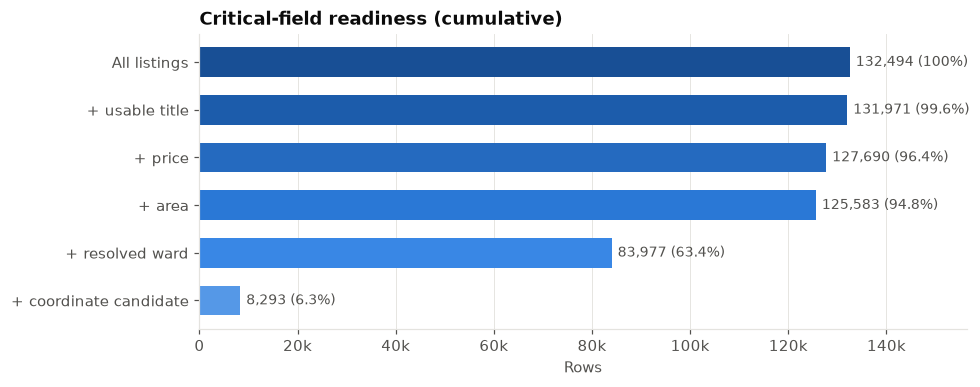

In [ ]:
title_text = df["title_raw"].astype("string")
usable_title = title_text.notna() & title_text.str.strip().ne("")
usable_price = pd.to_numeric(df["price_amount"], errors="coerce").gt(0)
usable_area = pd.to_numeric(df["area_value"], errors="coerce").gt(0)
resolved_current_ward = location_audit["ward_current"].notna()
coordinate_candidate = has_coordinates

readiness_masks = {
    "All listings": pd.Series(True, index=df.index),
    "+ usable title": usable_title,
    "+ price": usable_title & usable_price,
    "+ area": usable_title & usable_price & usable_area,
    "+ resolved ward": usable_title & usable_price & usable_area & resolved_current_ward,
    "+ coordinate candidate": usable_title
    & usable_price
    & usable_area
    & resolved_current_ward
    & coordinate_candidate,
}
readiness_funnel = pd.DataFrame(
    {
        "Readiness stage": list(readiness_masks),
        "Listings": [int(m.sum()) for m in readiness_masks.values()],
    }
)
funnel_chart(
    readiness_funnel.set_index("Readiness stage")["Listings"],
    title="Critical-field readiness (cumulative)",
)
plt.show()

### 09.2 Rental Title Usability

Descriptive usability only; no property type is inferred.

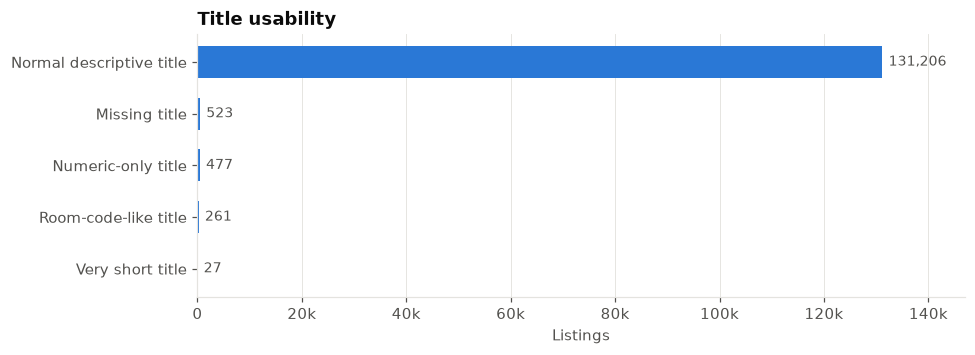

,source_code,title_raw,Title status
761,nhatrovn,01,Numeric-only title
775,nhatrovn,101,Numeric-only title
779,nhatrovn,P.001,Room-code-like title
782,nhatrovn,102,Numeric-only title
785,nhatrovn,101,Numeric-only title
832,nhatrovn,P.013,Room-code-like title
866,nhatrovn,PG01B,Room-code-like title
872,nhatrovn,G3,Room-code-like title
938,nhatrovn,KTX1,Very short title
944,nhatrovn,MB4,Very short title


In [ ]:
stripped_title = title_text.str.strip()
title_length = stripped_title.str.len()
numeric_title = stripped_title.str.fullmatch(r"\d+", na=False)
room_code_title = (
    stripped_title.str.fullmatch(r"(?i)(?:p(?:hòng)?[.\s_-]*)?[a-z]?\d{1,4}[a-z]?", na=False)
    & ~numeric_title
)

title_status = pd.Series("Normal descriptive title", index=df.index, dtype="string")
title_status.loc[title_text.isna()] = "Missing title"
title_status.loc[title_text.notna() & stripped_title.eq("")] = "Empty / whitespace title"
title_status.loc[title_length.between(1, 4) & ~numeric_title & ~room_code_title] = (
    "Very short title"
)
title_status.loc[numeric_title] = "Numeric-only title"
title_status.loc[room_code_title] = "Room-code-like title"

title_usability = title_status.value_counts()
bar_chart(title_usability, title="Title usability", xlabel="Listings")
plt.show()
df.assign(**{"Title status": title_status}).loc[
    title_status.isin(["Numeric-only title", "Room-code-like title", "Very short title"]),
    ["source_code", "title_raw", "Title status"],
].groupby("Title status", group_keys=False).head(4)

### 09.3 Price & Area Usability

Outliers stay usable candidates but need processing review. Raw price/area text is not in the latest-state view, so reparse agreement is measured in Notebook 02.

,Available,Positive,Statistical outlier,Suspicious low,Suspicious high,Requires review
Price,128213,128213,7475,1207,525,7475
Area,130362,130362,5292,1035,1176,5292


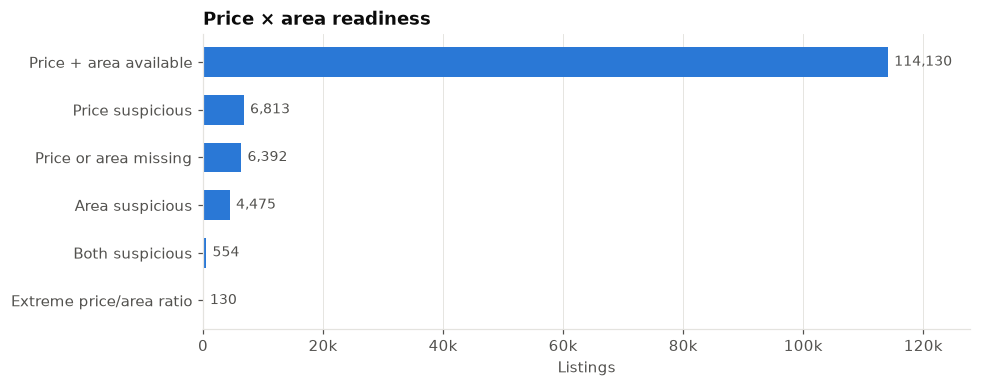

In [ ]:
price_numeric = pd.to_numeric(df["price_amount"], errors="coerce")
area_numeric = pd.to_numeric(df["area_value"], errors="coerce")
price_review = price_outlier_mask.fillna(False) | price_numeric.le(0).fillna(False)
area_review = area_outlier_mask.fillna(False) | area_numeric.le(0).fillna(False)

price_area_usability = pd.DataFrame(
    {
        "Available": [price_numeric.notna().sum(), area_numeric.notna().sum()],
        "Positive": [price_numeric.gt(0).sum(), area_numeric.gt(0).sum()],
        "Statistical outlier": [price_outlier_mask.sum(), area_outlier_mask.sum()],
        "Suspicious low": [
            price_numeric.lt(price_low_cut).sum(),
            area_numeric.lt(area_low_cut).sum(),
        ],
        "Suspicious high": [
            price_numeric.gt(price_high_cut).sum(),
            area_numeric.gt(area_high_cut).sum(),
        ],
        "Requires review": [price_review.sum(), area_review.sum()],
    },
    index=["Price", "Area"],
)
display(price_area_usability)

cross_field_status = pd.Series("Price + area available", index=df.index, dtype="string")
cross_field_status.loc[price_review & ~area_review] = "Price suspicious"
cross_field_status.loc[~price_review & area_review] = "Area suspicious"
cross_field_status.loc[price_review & area_review] = "Both suspicious"
cross_field_status.loc[price_numeric.isna() | area_numeric.isna()] = "Price or area missing"
cross_field_status.loc[relationship_audit["Price per Area"].ge(ratio_high_cut)] = (
    "Extreme price/area ratio"
)
bar_chart(cross_field_status.value_counts(), title="Price × area readiness", xlabel="Listings")
plt.show()

### 09.4 Location Resolution Readiness

Reuses the temporary parser and mapping; `df` is never overwritten.

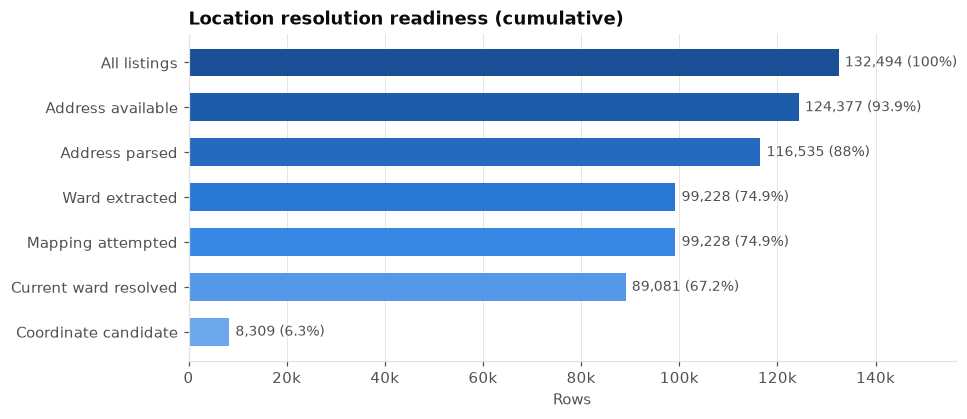

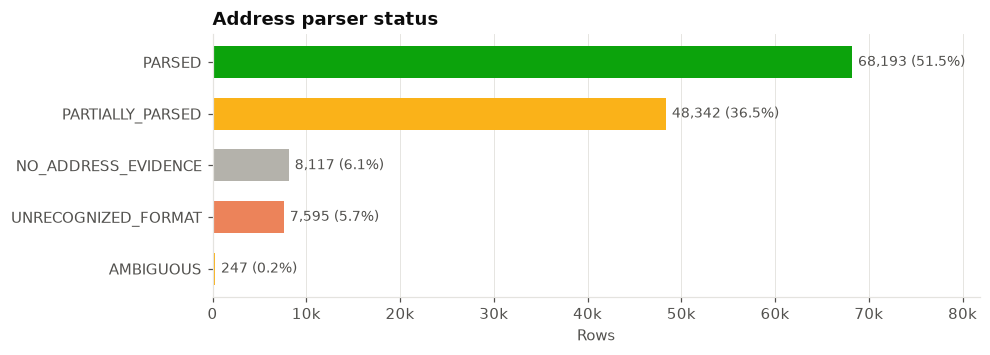

In [ ]:
parsed_address = location_audit["parse_status"].isin(["PARSED", "PARTIALLY_PARSED"])
ward_extracted = location_audit["ward_text_extracted"].notna()
mapping_attempted = location_audit["ward_mapping_status"].ne("MISSING")
location_resolution_masks = {
    "All listings": pd.Series(True, index=df.index),
    "Address available": address_available,
    "Address parsed": address_available & parsed_address,
    "Ward extracted": address_available & parsed_address & ward_extracted,
    "Mapping attempted": address_available & parsed_address & ward_extracted & mapping_attempted,
    "Current ward resolved": address_available & parsed_address & resolved_current_ward,
    "Coordinate candidate": address_available
    & parsed_address
    & resolved_current_ward
    & coordinate_candidate,
}
location_resolution_funnel = pd.Series(
    {k: int(m.sum()) for k, m in location_resolution_masks.items()}
)
funnel_chart(location_resolution_funnel, title="Location resolution readiness (cumulative)")
plt.show()
status_chart(
    location_audit["parse_status"].fillna("MISSING").value_counts(),
    tiers=STATUS_TIERS,
    title="Address parser status",
)
plt.show()

In [ ]:
location_audit.loc[
    location_audit["ward_mapping_status"].isin(["MAPPED", "AMBIGUOUS", "UNMAPPED"]),
    [
        "best_address_text",
        "ward_text_extracted",
        "district_text_extracted",
        "ward_current",
        "ward_mapping_status",
    ],
].groupby("ward_mapping_status", group_keys=False).head(3)

,best_address_text,ward_text_extracted,district_text_extracted,ward_current,ward_mapping_status
0,"Lý Chính Thắng, Phường 7 (Phường Võ Thị Sáu), ...",Phường 7 (Phường Võ Thị Sáu),Quận 3,NaN,UNMAPPED
1,"Nguyễn Thiện Thuật, Phường 3, Quận 3, TPHCM",Phường 3,Quận 3,Phường Bàn Cờ,MAPPED
2,"Bùi Hữu Nghĩa, Phường 2, Quận Bình Thạnh, TPHCM",Phường 2,Quận Bình Thạnh,Phường Gia Định,MAPPED
3,"Trường Chinh, Phường 15, Quận Tân Bình, TPHCM",Phường 15,Quận Tân Bình,NaN,AMBIGUOUS
4,"Trường Chinh, Phường 15, Quận Tân Bình, TPHCM",Phường 15,Quận Tân Bình,NaN,AMBIGUOUS
6,"Phan Văn Hớn, Phường Tân Thới Nhất, Quận 12, T...",Phường Tân Thới Nhất,Quận 12,Phường Đông Hưng Thuận,MAPPED
29,"Thành Thái, Phường 14, Quận 10, TPHCM",Phường 14,Quận 10,NaN,AMBIGUOUS
31,"Nguyễn Tri Phương, Phường 6, Quận 5, TPHCM",Phường 6,Quận 5,NaN,UNMAPPED
32,"Nguyễn Tri Phương, Phường 6, Quận 5, TPHCM",Phường 6,Quận 5,NaN,UNMAPPED


### 09.5 Coordinate Trust Readiness

Having a coordinate does not make it usable for radius search: points shared by many listings or by different addresses are suspicious.

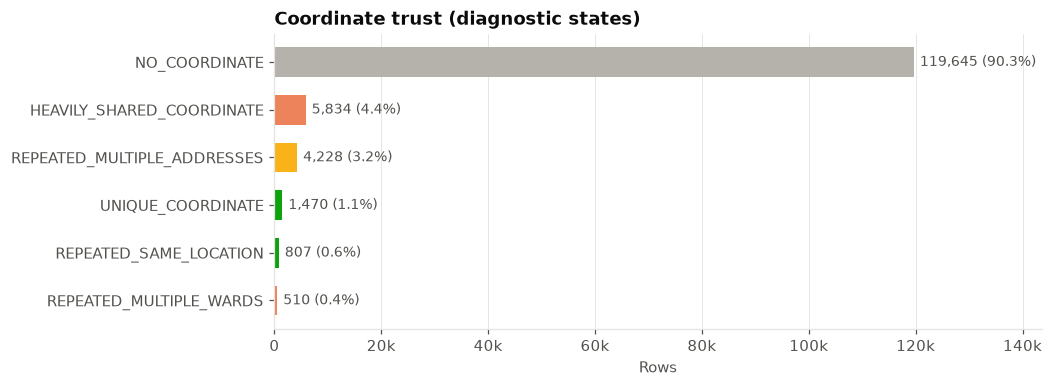

,lat_key,lon_key,Listings,Distinct addresses,Distinct wards,Distinct sources
1308,10.803558,106.641949,285,47,3,2
1386,10.806117,106.719341,236,33,3,2
1568,10.814095,106.621773,222,51,1,2
1649,10.819196,106.653244,190,48,0,2
1101,10.794777,106.621914,185,53,2,2
677,10.772981,106.661602,180,19,1,2
545,10.766117,106.617161,175,21,2,2
1759,10.829873,106.692741,171,27,2,2
1077,10.793849,106.641304,168,35,2,1
1420,10.807054,106.667713,166,42,2,2


In [ ]:
coordinate_audit = df[
    [
        "rental_post_id",
        "source_code",
        "best_address_text",
        "map_provider",
        "map_latitude",
        "map_longitude",
    ]
].copy()
coordinate_audit = audit_coordinate_trust(
    coordinate_audit.join(location_audit[["ward_current"]]), address_col="best_address_text"
)
coordinate_key = coordinate_audit[["map_latitude", "map_longitude"]].round(6)
coordinate_audit = coordinate_audit.assign(
    lat_key=coordinate_key["map_latitude"], lon_key=coordinate_key["map_longitude"]
)
coordinate_group_stats = (
    coordinate_audit.loc[coordinate_audit["coordinate_pair_valid"]]
    .groupby(["lat_key", "lon_key"])
    .agg(
        Listings=("rental_post_id", "size"),
        **{
            "Distinct addresses": ("best_address_text", "nunique"),
            "Distinct wards": ("ward_current", "nunique"),
            "Distinct sources": ("source_code", "nunique"),
        },
    )
    .reset_index()
)
coordinate_audit = coordinate_audit.merge(
    coordinate_group_stats, on=["lat_key", "lon_key"], how="left"
)
valid_coordinate = coordinate_audit["coordinate_pair_valid"]

coordinate_trust_state = pd.Series("NO_COORDINATE", index=coordinate_audit.index, dtype="string")
coordinate_trust_state.loc[valid_coordinate & coordinate_audit["Listings"].eq(1)] = (
    "UNIQUE_COORDINATE"
)
coordinate_trust_state.loc[valid_coordinate & coordinate_audit["Listings"].gt(1)] = (
    "REPEATED_SAME_LOCATION"
)
coordinate_trust_state.loc[valid_coordinate & coordinate_audit["Distinct addresses"].gt(1)] = (
    "REPEATED_MULTIPLE_ADDRESSES"
)
coordinate_trust_state.loc[valid_coordinate & coordinate_audit["Distinct wards"].gt(1)] = (
    "REPEATED_MULTIPLE_WARDS"
)
coordinate_trust_state.loc[valid_coordinate & coordinate_audit["Listings"].ge(50)] = (
    "HEAVILY_SHARED_COORDINATE"
)
coordinate_audit["coordinate_trust_state"] = coordinate_trust_state

status_chart(
    coordinate_trust_state.value_counts(),
    tiers={
        "UNIQUE_COORDINATE": "good",
        "REPEATED_SAME_LOCATION": "good",
        "REPEATED_MULTIPLE_ADDRESSES": "warning",
        "REPEATED_MULTIPLE_WARDS": "serious",
        "HEAVILY_SHARED_COORDINATE": "serious",
    },
    title="Coordinate trust (diagnostic states)",
)
plt.show()
coordinate_group_stats.sort_values("Listings", ascending=False).head(10)

### 09.6 Source-specific Readiness

The heatmap shows readiness (higher is better); review rates (lower is better) are listed below it.

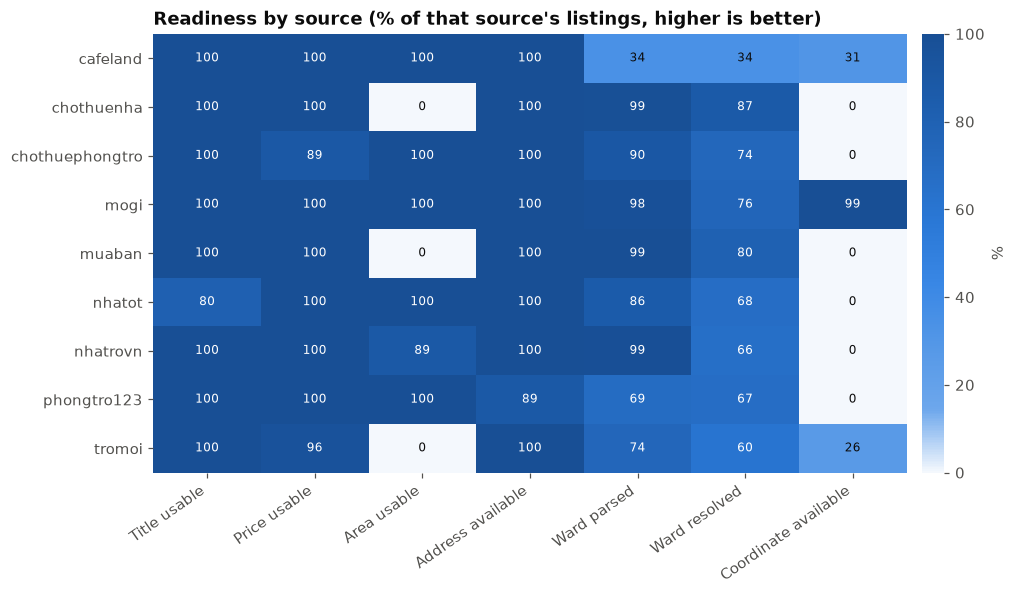

,Coordinate requires review,Price requires review
source_code,,
cafeland,88.6,6.5
chothuenha,100.0,6.0
chothuephongtro,100.0,17.3
mogi,88.8,1.0
muaban,100.0,1.7
nhatot,100.0,1.0
nhatrovn,100.0,0.6
phongtro123,100.0,0.7
tromoi,82.4,2.0


In [ ]:
source_readiness_flags = pd.DataFrame(
    {
        "source_code": df["source_code"],
        "Title usable": usable_title,
        "Price usable": usable_price,
        "Area usable": usable_area,
        "Address available": address_available,
        "Ward parsed": ward_extracted,
        "Ward resolved": resolved_current_ward,
        "Coordinate available": coordinate_candidate,
        "Coordinate requires review": ~coordinate_audit["coordinate_trust_state"].isin(
            ["UNIQUE_COORDINATE", "REPEATED_SAME_LOCATION"]
        ),
        "Price requires review": price_review,
    }
)
source_readiness = source_readiness_flags.groupby("source_code").mean().mul(100).round(1)
review_columns = ["Coordinate requires review", "Price requires review"]
heatmap(
    source_readiness.drop(columns=review_columns),
    title="Readiness by source (% of that source's listings, higher is better)",
    vmax=100,
    label="%",
)
plt.show()
source_readiness[review_columns]

### 09.7 Duplicate / Repost Evidence

Candidates need the same normalized address, positive price and positive area. Shared coordinates alone are never evidence; nothing is merged or deleted.

In [ ]:
duplicate_audit = relationship_audit[
    [
        "rental_post_id",
        "source_code",
        "source_listing_id",
        "title_raw",
        "Price",
        "Area",
        "best_address_text",
    ]
].copy()
duplicate_audit["address_key"] = (
    duplicate_audit["best_address_text"]
    .astype("string")
    .str.normalize("NFKC")
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .replace("", pd.NA)
)
candidate_mask = (
    duplicate_audit["address_key"].notna()
    & duplicate_audit["Price"].gt(0)
    & duplicate_audit["Area"].gt(0)
)
candidate_groups = (
    duplicate_audit.loc[candidate_mask]
    .groupby(["address_key", "Price", "Area"], dropna=False)
    .filter(lambda group: len(group) > 1)
    .copy()
)
candidate_groups["Candidate group"] = (
    candidate_groups.groupby(["address_key", "Price", "Area"], sort=False).ngroup().add(1)
)
group_scope = (
    candidate_groups.groupby("Candidate group")["source_code"]
    .nunique()
    .gt(1)
    .map({True: "CROSS_SOURCE", False: "SAME_SOURCE"})
)
candidate_groups["Scope"] = candidate_groups["Candidate group"].map(group_scope)
duplicate_candidate_summary = (
    candidate_groups.groupby("Scope")
    .agg(
        **{
            "Candidate groups": ("Candidate group", "nunique"),
            "Candidate listings": ("rental_post_id", "size"),
        }
    )
    .reindex(["SAME_SOURCE", "CROSS_SOURCE"], fill_value=0)
)
display(duplicate_candidate_summary)
candidate_groups.sort_values(["Candidate group", "source_code"])[
    ["Candidate group", "source_code", "title_raw", "Price", "Area", "best_address_text"]
].head(10)

,Candidate groups,Candidate listings
Scope,,
SAME_SOURCE,11594,36849
CROSS_SOURCE,15,49


,Candidate group,source_code,title_raw,Price,Area,best_address_text
4,1,mogi,🏡 PHÒNG TRỌ GIÁ RẺ Mới 100% - Full Nội Thất - ...,3000000.0,30.0,"Trường Chinh, Phường 15, Quận Tân Bình, TPHCM"
158,1,mogi,💥 Phòng cửa sổ thoáng Trường Chinh gần BigC NEW!!,3000000.0,30.0,"Trường Chinh, Phường 15, Quận Tân Bình, TPHCM"
5,2,mogi,🏡Phòng Trọ Mới Giá Rẻ - Full Nội Thất + Ban Cô...,3000000.0,35.0,"Tô Ký, Phường Trung Mỹ Tây, Quận 12, TPHCM"
4966,2,mogi,⭐ PHÒNG TRỌ GIÁ RẺ - FULL Nội Thất - Ngay phần...,3000000.0,35.0,"Tô Ký, Phường Trung Mỹ Tây, Quận 12, TPHCM"
4973,2,mogi,⭐ PHÒNG TRỌ GIÁ RẺ - FULL NỘI THẤT - Ngay phần...,3000000.0,35.0,"Tô Ký, Phường Trung Mỹ Tây, Quận 12, TPHCM"
6,3,mogi,🏡 Phòng Trọ Giá Rẻ - Full Nội Thất & Ban Công ...,3000000.0,30.0,"Phan Văn Hớn, Phường Tân Thới Nhất, Quận 12, T..."
230,3,mogi,🏡Phòng Trọ Cao Cấp Mới Xây 100% - Full Nội Thấ...,3000000.0,30.0,"Phan Văn Hớn, Phường Tân Thới Nhất, Quận 12, T..."
9589,3,mogi,"Phòng Gác Mới Xây Full Nội Thất _Ban Công, Cửa...",3000000.0,30.0,"Phan Văn Hớn, Phường Tân Thới Nhất, Quận 12, T..."
17116,3,mogi,🏡 Căn Hộ Full Nội Thất - Mới 100% - Ngã Tư An ...,3000000.0,30.0,"Phan Văn Hớn, Phường Tân Thới Nhất, Quận 12, T..."
17118,3,mogi,"🏡 Căn Hộ Full Nội Thất, Mới 100% - Ngã Tư An S...",3000000.0,30.0,"Phan Văn Hớn, Phường Tân Thới Nhất, Quận 12, T..."


### 09.8 Overall Readiness Summary

In [ ]:
overall_readiness = pd.DataFrame(
    [
        [
            "Identifier integrity",
            "HEALTHY" if df["rental_post_id"].is_unique else "REQUIRES INVESTIGATION",
            f"{df['rental_post_id'].nunique():,} unique IDs / {len(df):,} rows",
        ],
        [
            "Missing data",
            "PARTIAL",
            f"{readiness_funnel.iloc[-2]['Listings']:,} reach the resolved-ward stage",
        ],
        ["Title usability", "PARTIAL", f"{usable_title.sum():,} non-empty titles"],
        [
            "Price usability",
            "REQUIRES PROCESSING",
            f"{usable_price.sum():,} positive; {price_review.sum():,} review flags",
        ],
        [
            "Area usability",
            "REQUIRES PROCESSING",
            f"{usable_area.sum():,} positive; {area_review.sum():,} review flags",
        ],
        ["Address parsing", "PARTIAL", f"{parsed_address.sum():,} parsed or partially parsed"],
        [
            "Administrative mapping",
            "PARTIAL",
            f"{resolved_current_ward.sum():,} current wards resolved",
        ],
        [
            "Coordinate readiness",
            "REQUIRES INVESTIGATION",
            f"{coordinate_candidate.sum():,} complete pairs; {coordinate_audit['has_trusted_coordinate'].sum():,} trust candidates",
        ],
        [
            "Source consistency",
            "REQUIRES PROCESSING",
            f"{len(source_readiness):,} sources compared",
        ],
        [
            "Duplicate risk",
            "REQUIRES INVESTIGATION",
            f"{candidate_groups['Candidate group'].nunique():,} candidate groups",
        ],
    ],
    columns=["Readiness area", "Status", "Evidence"],
)
overall_readiness

,Readiness area,Status,Evidence
0,Identifier integrity,HEALTHY,"132,494 unique IDs / 132,494 rows"
1,Missing data,PARTIAL,"83,977 reach the resolved-ward stage"
2,Title usability,PARTIAL,"131,971 non-empty titles"
3,Price usability,REQUIRES PROCESSING,"128,213 positive; 7,475 review flags"
4,Area usability,REQUIRES PROCESSING,"130,362 positive; 5,292 review flags"
5,Address parsing,PARTIAL,"116,535 parsed or partially parsed"
6,Administrative mapping,PARTIAL,"89,276 current wards resolved"
7,Coordinate readiness,REQUIRES INVESTIGATION,"12,849 complete pairs; 2,277 trust candidates"
8,Source consistency,REQUIRES PROCESSING,9 sources compared
9,Duplicate risk,REQUIRES INVESTIGATION,"11,609 candidate groups"


## 10. Data Quality Findings

> **Why:** Summarise what the raw snapshot tells us. These describe the snapshot only, not true market supply or prices.

In [ ]:
display(
    Markdown(
        f"""
| Area | Finding |
|---|---|
| **Healthy** | Identifiers are unique across **{len(df):,}** records; no negative price, area or active-day values. |
| **Missing data** | **{price_numeric.isna().sum():,}** prices, **{area_numeric.isna().sum():,}** areas and **{(~address_available).sum():,}** best addresses are missing; only **{has_coordinates.mean():.1%}** have coordinates. |
| **Price / area** | IQR flags **{price_outlier_mask.sum():,}** prices and **{area_outlier_mask.sum():,}** areas for review (not automatic invalidation). |
| **Text** | **{title_status.isin(['Numeric-only title', 'Room-code-like title', 'Very short title']).sum():,}** titles are short, numeric or room-code-like. |
| **Address / mapping** | **{location_audit['parse_status'].isin(['UNRECOGNIZED_FORMAT', 'MISSING']).sum():,}** addresses fail parsing; **{location_audit['ward_mapping_status'].isin(['AMBIGUOUS', 'UNMAPPED']).sum():,}** wards stay ambiguous or unmapped. |
| **Sources** | Field readiness and price/area distributions differ by source; compare locations only with source composition in mind. |
| **Duplicates** | **{candidate_groups['Candidate group'].nunique():,}** possible repost groups (address + price + area); none confirmed or removed. |
| **Relationships** | Price × area: Pearson **{relationship_correlation.loc[1, 'Value']:.3f}**, Spearman **{relationship_correlation.loc[2, 'Value']:.3f}**. |
"""
    )
)


| Area | Finding |
|---|---|
| **Healthy** | Identifiers are unique across **132,494** records; no negative price, area or active-day values. |
| **Missing data** | **4,281** prices, **2,132** areas and **8,117** best addresses are missing; only **9.7%** have coordinates. |
| **Price / area** | IQR flags **7,475** prices and **5,292** areas for review (not automatic invalidation). |
| **Text** | **765** titles are short, numeric or room-code-like. |
| **Address / mapping** | **7,595** addresses fail parsing; **10,191** wards stay ambiguous or unmapped. |
| **Sources** | Field readiness and price/area distributions differ by source; compare locations only with source composition in mind. |
| **Duplicates** | **11,609** possible repost groups (address + price + area); none confirmed or removed. |
| **Relationships** | Price × area: Pearson **0.011**, Spearman **0.304**. |


## 11. Cleaning & Processing Requirements

> **Why:** Turn each finding into a processing requirement. EDA stops here; Notebook 02 implements them.

In [ ]:
processing_requirements = pd.DataFrame(
    [
        [
            "Non-descriptive titles",
            f"{title_status.ne('Normal descriptive title').sum():,} titles",
            "Standardize text; flag unusable titles",
        ],
        [
            "Price missing or flagged",
            f"{price_numeric.isna().sum():,} missing; {price_review.sum():,} flagged",
            "Reparse raw price by source; validate units",
        ],
        [
            "Area missing or flagged",
            f"{area_numeric.isna().sum():,} missing; {area_review.sum():,} flagged",
            "Reparse raw area; validate units and extremes",
        ],
        [
            "Price/area anomalies",
            f"{relationship_issue_summary['Affected Rows'].sum():,} non-exclusive flags",
            "Cross-field validation without deleting outliers",
        ],
        [
            "Address parser gaps",
            f"{location_audit['parse_status'].isin(['UNRECOGNIZED_FORMAT', 'MISSING']).sum():,} failures",
            "Improve parser; keep provenance",
        ],
        [
            "Unresolved wards",
            f"{location_audit['ward_mapping_status'].isin(['AMBIGUOUS', 'UNMAPPED']).sum():,} ambiguous/unmapped",
            "Explicit unresolved state; never force a ward",
        ],
        [
            "Coordinate trust",
            f"{coordinate_candidate.sum():,} complete pairs",
            "Classify provider, shared points and address consistency",
        ],
        [
            "Source differences",
            f"{len(source_readiness):,} sources",
            "Source-specific parsing rules",
        ],
        [
            "Possible reposts",
            f"{candidate_groups['Candidate group'].nunique():,} groups",
            "Auditable candidate links; no deletion",
        ],
        [
            "Temporal semantics",
            f"{(df['first_observed_at'] > df['last_observed_at']).sum():,} chronology exceptions",
            "Testable lifecycle checks",
        ],
    ],
    columns=["Observed problem", "Evidence", "Required processing"],
)
processing_requirements

,Observed problem,Evidence,Required processing
0,Non-descriptive titles,"1,288 titles",Standardize text; flag unusable titles
1,Price missing or flagged,"4,281 missing; 7,475 flagged",Reparse raw price by source; validate units
2,Area missing or flagged,"2,132 missing; 5,292 flagged",Reparse raw area; validate units and extremes
3,Price/area anomalies,"43,032 non-exclusive flags",Cross-field validation without deleting outliers
4,Address parser gaps,"7,595 failures",Improve parser; keep provenance
5,Unresolved wards,"10,191 ambiguous/unmapped",Explicit unresolved state; never force a ward
6,Coordinate trust,"12,849 complete pairs","Classify provider, shared points and address c..."
7,Source differences,9 sources,Source-specific parsing rules
8,Possible reposts,"11,609 groups",Auditable candidate links; no deletion
9,Temporal semantics,5 chronology exceptions,Testable lifecycle checks


## Summary

In [ ]:
display(
    Markdown(
        f"""
**Key findings**

- The snapshot holds **{len(df):,}** listings from **{df.source_code.nunique()}** sources; **{source_distribution.index[0]}** alone supplies {source_distribution.iloc[0] / len(df):.0%}.
- **{readiness_funnel.iloc[3]['Listings']:,}** listings ({readiness_funnel.iloc[3]['Listings'] / len(df):.0%}) have a usable title, price and area; only **{readiness_funnel.iloc[-1]['Listings']:,}** also have a resolved ward and a coordinate.
- Coordinates are the weakest field: **{has_coordinates.mean():.1%}** coverage, and many points are shared by unrelated addresses.
- Price and area are heavily skewed (Pearson {relationship_correlation.loc[1, 'Value']:.2f} vs Spearman {relationship_correlation.loc[2, 'Value']:.2f}), so robust statistics and IQR flags are used instead of means.

**Next step:** Notebook 02 implements the requirements in section 11 and publishes an audited Silver dataset.
"""
    )
)


**Key findings**

- The snapshot holds **132,494** listings from **9** sources; **phongtro123** alone supplies 54%.
- **125,583** listings (95%) have a usable title, price and area; only **8,293** also have a resolved ward and a coordinate.
- Coordinates are the weakest field: **9.7%** coverage, and many points are shared by unrelated addresses.
- Price and area are heavily skewed (Pearson 0.01 vs Spearman 0.30), so robust statistics and IQR flags are used instead of means.

**Next step:** Notebook 02 implements the requirements in section 11 and publishes an audited Silver dataset.
